---

Exploring Regression Models pre-processing, training, validation and effect of regularization

* Predict age of the possum
* Utilize L1 and L2 regression
* Look how Lasso and ElasticNet reduces parameters
* Look at cross validation

---

In [1]:
import pandas as pd
import numpy as np

In [2]:
from pathlib import Path

In [3]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt

In [5]:
possum_dataset = pd.read_csv(Path('data','possum.csv'))
possum_dataset

,case,site,Pop,sex,age,hdlngth,skullw,totlngth,taill,footlgth,earconch,eye,chest,belly
0,1,1,Vic,m,8.0,94.1,60.4,89.0,36.0,74.5,54.5,15.2,28.0,36.0
1,2,1,Vic,f,6.0,92.5,57.6,91.5,36.5,72.5,51.2,16.0,28.5,33.0
2,3,1,Vic,f,6.0,94.0,60.0,95.5,39.0,75.4,51.9,15.5,30.0,34.0
3,4,1,Vic,f,6.0,93.2,57.1,92.0,38.0,76.1,52.2,15.2,28.0,34.0
4,5,1,Vic,f,2.0,91.5,56.3,85.5,36.0,71.0,53.2,15.1,28.5,33.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99,100,7,other,m,1.0,89.5,56.0,81.5,36.5,66.0,46.8,14.8,23.0,27.0
100,101,7,other,m,1.0,88.6,54.7,82.5,39.0,64.4,48.0,14.0,25.0,33.0
101,102,7,other,f,6.0,92.4,55.0,89.0,38.0,63.5,45.4,13.0,25.0,30.0
102,103,7,other,m,4.0,91.5,55.2,82.5,36.5,62.9,45.9,15.4,25.0,29.0


In [6]:
possum_dataset.describe()

,case,site,age,hdlngth,skullw,totlngth,taill,footlgth,earconch,eye,chest,belly
count,104.000000,104.000000,102.000000,104.000000,104.000000,104.000000,104.000000,103.000000,104.000000,104.000000,104.000000,104.000000
mean,52.500000,3.625000,3.833333,92.602885,56.883654,87.088462,37.009615,68.459223,48.130769,15.046154,27.000000,32.586538
std,30.166206,2.349086,1.909244,3.573349,3.113426,4.310549,1.959518,4.395306,4.109380,1.050374,2.045597,2.761949
min,1.000000,1.000000,1.000000,82.500000,50.000000,75.000000,32.000000,60.300000,40.300000,12.800000,22.000000,25.000000
25%,26.750000,1.000000,2.250000,90.675000,54.975000,84.000000,35.875000,64.600000,44.800000,14.400000,25.500000,31.000000
50%,52.500000,3.000000,3.000000,92.800000,56.350000,88.000000,37.000000,68.000000,46.800000,14.900000,27.000000,32.500000
75%,78.250000,6.000000,5.000000,94.725000,58.100000,90.000000,38.000000,72.500000,52.000000,15.725000,28.000000,34.125000
max,104.000000,7.000000,9.000000,103.100000,68.600000,96.500000,43.000000,77.900000,56.200000,17.800000,32.000000,40.000000


In [7]:
nan_counts_per_column = possum_dataset.isna().sum()
print(nan_counts_per_column)

case        0
site        0
Pop         0
sex         0
age         2
hdlngth     0
skullw      0
totlngth    0
taill       0
footlgth    1
earconch    0
eye         0
chest       0
belly       0
dtype: int64


In [246]:
nan_rows = possum_dataset[possum_dataset.isna().any(axis=1)]
print(nan_rows)

    case  site  Pop sex  age  hdlngth  skullw  totlngth  taill  footlgth  \
40    41     2  Vic   f  5.0     88.4    57.0      83.0   36.5       NaN   
43    44     2  Vic   m  NaN     85.1    51.5      76.0   35.5      70.3   
45    46     2  Vic   m  NaN     91.4    54.4      84.0   35.0      72.8   

    earconch   eye  chest  belly   log_age  exp_dec_age  tanh_age  
40      40.3  15.9   27.0   30.5  1.609438     0.006738 -0.999909  
43      52.6  14.4   23.0   27.0       NaN          NaN       NaN  
45      51.2  14.4   24.5   35.0       NaN          NaN       NaN  


<Axes: xlabel='hdlngth', ylabel='age'>

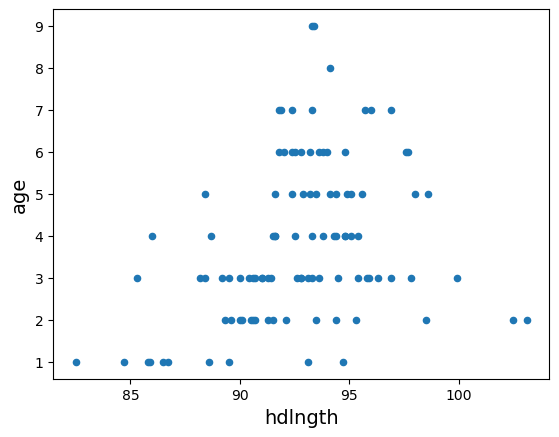

In [247]:
possum_dataset.plot.scatter(x='hdlngth', y='age')

<Axes: xlabel='totlngth', ylabel='footlgth'>

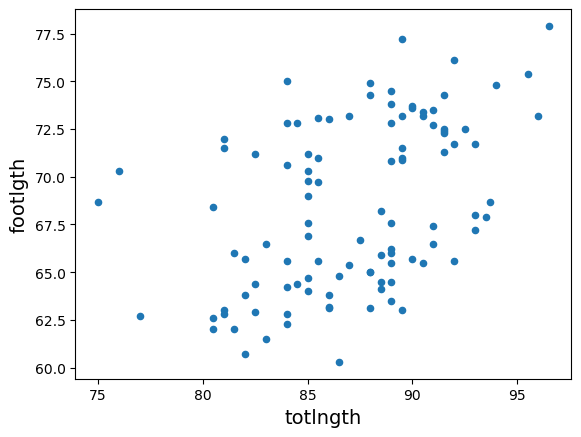

In [249]:
possum_dataset.plot.scatter(x='totlngth', y='footlgth')

In [8]:
possum_dataset_processed = possum_dataset.dropna()
possum_dataset_processed

,case,site,Pop,sex,age,hdlngth,skullw,totlngth,taill,footlgth,earconch,eye,chest,belly
0,1,1,Vic,m,8.0,94.1,60.4,89.0,36.0,74.5,54.5,15.2,28.0,36.0
1,2,1,Vic,f,6.0,92.5,57.6,91.5,36.5,72.5,51.2,16.0,28.5,33.0
2,3,1,Vic,f,6.0,94.0,60.0,95.5,39.0,75.4,51.9,15.5,30.0,34.0
3,4,1,Vic,f,6.0,93.2,57.1,92.0,38.0,76.1,52.2,15.2,28.0,34.0
4,5,1,Vic,f,2.0,91.5,56.3,85.5,36.0,71.0,53.2,15.1,28.5,33.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99,100,7,other,m,1.0,89.5,56.0,81.5,36.5,66.0,46.8,14.8,23.0,27.0
100,101,7,other,m,1.0,88.6,54.7,82.5,39.0,64.4,48.0,14.0,25.0,33.0
101,102,7,other,f,6.0,92.4,55.0,89.0,38.0,63.5,45.4,13.0,25.0,30.0
102,103,7,other,m,4.0,91.5,55.2,82.5,36.5,62.9,45.9,15.4,25.0,29.0


In [250]:
possum_dataset['log_age']=np.log(possum_dataset['age'])
possum_dataset['exp_dec_age']=np.exp(-possum_dataset['age'])
possum_dataset['tanh_age']=np.tanh(possum_dataset['age'])

In [251]:
numerical_columns_list = list(possum_dataset.select_dtypes(include=np.number).columns)
numerical_columns_list

['case',
 'site',
 'age',
 'hdlngth',
 'skullw',
 'totlngth',
 'taill',
 'footlgth',
 'earconch',
 'eye',
 'chest',
 'belly',
 'log_age',
 'exp_dec_age',
 'tanh_age']

In [252]:
from sklearn.impute import SimpleImputer

most_frequent_imputer = SimpleImputer(strategy="most_frequent")

In [253]:
#help(SimpleImputer)

In [254]:
most_frequent_imputer.fit(possum_dataset[numerical_columns_list])

SimpleImputer(strategy='most_frequent')

In [255]:
most_frequent_imputer.statistics_

array([1.00000000e+00, 1.00000000e+00, 3.00000000e+00, 9.33000000e+01,
       5.76000000e+01, 8.90000000e+01, 3.80000000e+01, 7.32000000e+01,
       4.49000000e+01, 1.44000000e+01, 2.80000000e+01, 3.20000000e+01,
       1.09861229e+00, 4.97870684e-02, 9.95054754e-01])

In [256]:
median_imputer = SimpleImputer(strategy="median")

In [257]:
median_imputer.fit(possum_dataset[numerical_columns_list])
print(median_imputer.statistics_)

[5.25000000e+01 3.00000000e+00 3.00000000e+00 9.28000000e+01
 5.63500000e+01 8.80000000e+01 3.70000000e+01 6.80000000e+01
 4.68000000e+01 1.49000000e+01 2.70000000e+01 3.25000000e+01
 1.09861229e+00 4.97870684e-02 9.95054754e-01]


In [258]:
median_imputer

SimpleImputer(strategy='median')

In [259]:
mean_imputer = SimpleImputer(strategy="mean")

In [260]:
mean_imputer.fit(possum_dataset[numerical_columns_list])
print(mean_imputer.statistics_)

[5.25000000e+01 3.62500000e+00 3.83333333e+00 9.26028846e+01
 5.68836538e+01 8.70884615e+01 3.70096154e+01 6.84592233e+01
 4.81307692e+01 1.50461538e+01 2.70000000e+01 3.25865385e+01
 1.20274584e+00 7.42071816e-02 9.69569918e-01]


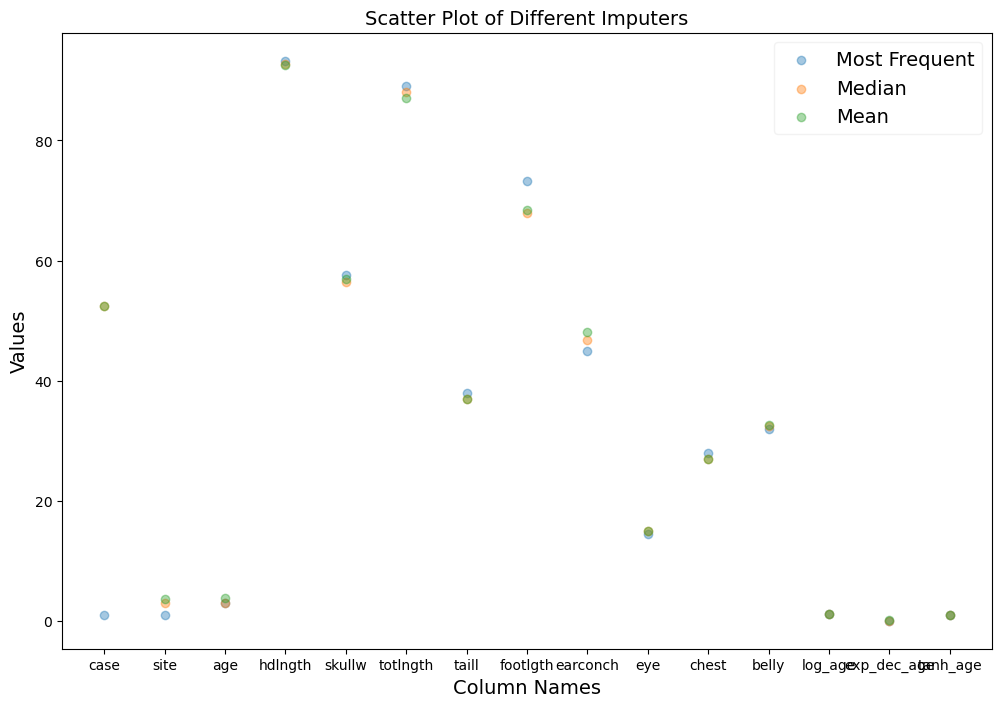

In [261]:
plt.figure(figsize=(12, 8))
plt.scatter(numerical_columns_list, 
            most_frequent_imputer.statistics_, 
            label="Most Frequent",
            alpha=0.4)
plt.scatter(numerical_columns_list, 
            median_imputer.statistics_, 
            label="Median",
            alpha=0.4)
plt.scatter(numerical_columns_list, 
            mean_imputer.statistics_, 
            label="Mean",
            alpha=0.4)
plt.legend(loc='upper right', framealpha=0.25)
plt.xlabel("Column Names")
plt.ylabel("Values")
plt.title("Scatter Plot of Different Imputers")
plt.show()

In [262]:
X = median_imputer.transform(possum_dataset[numerical_columns_list])
print(median_imputer.feature_names_in_)
print(X[:5,:])

['case' 'site' 'age' 'hdlngth' 'skullw' 'totlngth' 'taill' 'footlgth'
 'earconch' 'eye' 'chest' 'belly' 'log_age' 'exp_dec_age' 'tanh_age']
[[1.00000000e+00 1.00000000e+00 8.00000000e+00 9.41000000e+01
  6.04000000e+01 8.90000000e+01 3.60000000e+01 7.45000000e+01
  5.45000000e+01 1.52000000e+01 2.80000000e+01 3.60000000e+01
  2.07944154e+00 3.35462628e-04 9.99999775e-01]
 [2.00000000e+00 1.00000000e+00 6.00000000e+00 9.25000000e+01
  5.76000000e+01 9.15000000e+01 3.65000000e+01 7.25000000e+01
  5.12000000e+01 1.60000000e+01 2.85000000e+01 3.30000000e+01
  1.79175947e+00 2.47875218e-03 9.99987712e-01]
 [3.00000000e+00 1.00000000e+00 6.00000000e+00 9.40000000e+01
  6.00000000e+01 9.55000000e+01 3.90000000e+01 7.54000000e+01
  5.19000000e+01 1.55000000e+01 3.00000000e+01 3.40000000e+01
  1.79175947e+00 2.47875218e-03 9.99987712e-01]
 [4.00000000e+00 1.00000000e+00 6.00000000e+00 9.32000000e+01
  5.71000000e+01 9.20000000e+01 3.80000000e+01 7.61000000e+01
  5.22000000e+01 1.52000000e+01 2.

In [263]:
possum_dataset_median_transformed = pd.DataFrame(X, 
                                                 columns=numerical_columns_list,
                                                 index=possum_dataset.index
                                                )
possum_dataset_median_transformed.sample(10)

,case,site,age,hdlngth,skullw,totlngth,taill,footlgth,earconch,eye,chest,belly,log_age,exp_dec_age,tanh_age
66,67.0,5.0,4.0,93.3,57.6,85.0,36.5,64.7,44.1,16.5,27.5,29.5,1.386294,0.018316,0.999329
4,5.0,1.0,2.0,91.5,56.3,85.5,36.0,71.0,53.2,15.1,28.5,33.0,0.693147,0.135335,0.964028
17,18.0,1.0,2.0,93.5,55.7,90.0,36.0,73.7,55.4,15.3,28.0,32.0,0.693147,0.135335,0.964028
2,3.0,1.0,6.0,94.0,60.0,95.5,39.0,75.4,51.9,15.5,30.0,34.0,1.791759,0.002479,0.999988
48,49.0,3.0,4.0,95.4,59.2,85.0,37.0,69.0,45.0,15.9,29.5,35.5,1.386294,0.018316,0.999329
61,62.0,5.0,3.0,91.3,58.0,90.5,39.0,65.5,41.3,16.0,27.0,32.0,1.098612,0.049787,0.995055
89,90.0,7.0,3.0,92.6,54.6,85.0,38.5,69.8,44.8,14.5,25.5,32.5,1.098612,0.049787,0.995055
16,17.0,1.0,1.0,94.7,67.7,89.5,36.5,73.2,53.2,14.7,29.0,31.0,0.000000,0.367879,0.761594
8,9.0,1.0,9.0,93.4,56.3,91.5,37.0,72.4,52.9,15.5,28.0,33.0,2.197225,0.000123,1.000000
77,78.0,6.0,1.0,86.5,51.0,81.0,36.5,63.0,44.3,13.2,23.0,28.0,0.000000,0.367879,0.761594


In [264]:
# check if imputer worked
nan_counts_per_column_tr = possum_dataset_median_transformed.isna().sum()
print(nan_counts_per_column_tr)

case           0
site           0
age            0
hdlngth        0
skullw         0
totlngth       0
taill          0
footlgth       0
earconch       0
eye            0
chest          0
belly          0
log_age        0
exp_dec_age    0
tanh_age       0
dtype: int64


---

* Look into shuffling dataset into test and train utilizing age of possum

---

<Axes: >

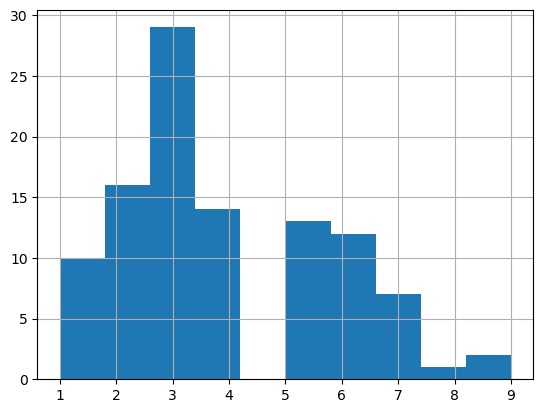

In [265]:
possum_dataset_median_transformed.age.hist()

In [266]:
possum_dataset_median_transformed["age_cat"] = pd.cut(possum_dataset_median_transformed["age"],
                               bins=[0., 2.5, 3.5, 4., 6., np.inf],
                               labels=[1, 2, 3, 4, 5])

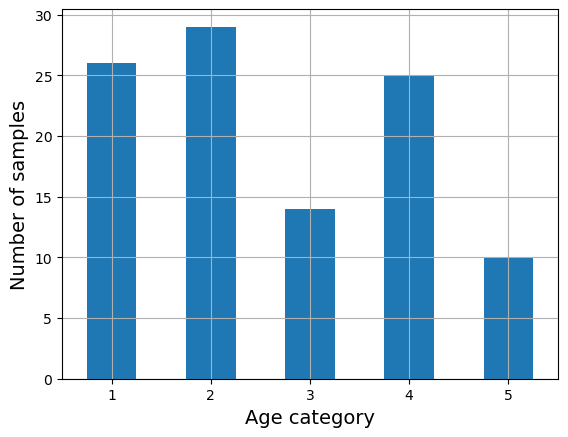

In [267]:
possum_dataset_median_transformed["age_cat"].value_counts().sort_index().plot.bar(rot=0, grid=True)
plt.xlabel("Age category")
plt.ylabel("Number of samples")
plt.show()

In [268]:
from sklearn.model_selection import StratifiedShuffleSplit

splitter = StratifiedShuffleSplit(n_splits=10, test_size=0.2, random_state=42)
possum_data_strat_splits = []
for train_index, test_index in splitter.split(possum_dataset_median_transformed, 
                                              possum_dataset_median_transformed["age_cat"]):
    possum_data_train_set_n = possum_dataset_median_transformed.iloc[train_index]
    possum_data_test_set_n = possum_dataset_median_transformed.iloc[test_index]
    possum_data_strat_splits.append([possum_data_train_set_n, possum_data_test_set_n])

In [269]:
possum_data_train_set, possum_data_test_set = possum_data_strat_splits[0]

In [270]:
possum_data_train_set, possum_data_test_set = train_test_split(
    possum_dataset_median_transformed, 
    test_size=0.2, 
    stratify=possum_dataset_median_transformed["age_cat"], 
    random_state=42)

In [271]:
possum_data_test_set["age_cat"].value_counts()/len(possum_data_test_set)

age_cat
2    0.285714
1    0.238095
4    0.238095
3    0.142857
5    0.095238
Name: count, dtype: float64

In [272]:
possum_data_train_set["age_cat"].value_counts()/len(possum_data_train_set)

age_cat
2    0.277108
1    0.253012
4    0.240964
3    0.132530
5    0.096386
Name: count, dtype: float64

<Axes: xlabel='age_cat'>

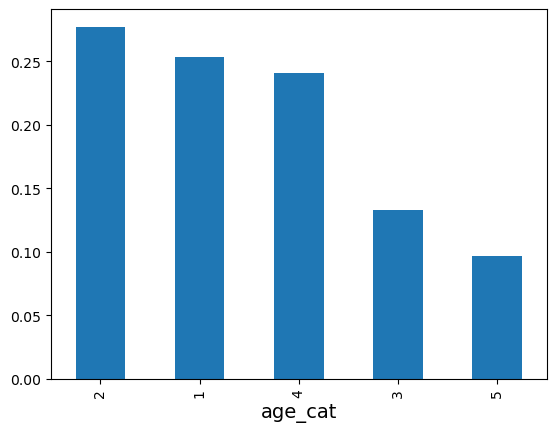

In [273]:
pd.Series(possum_data_train_set["age_cat"].value_counts()/len(possum_data_train_set)).plot.bar()

<Axes: xlabel='age_cat'>

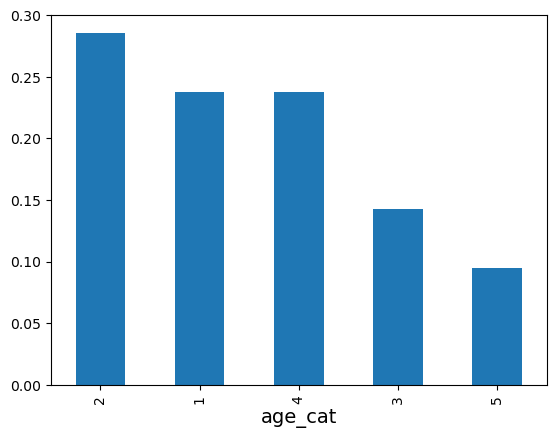

In [274]:
pd.Series(possum_data_test_set["age_cat"].value_counts()/len(possum_data_test_set)).plot.bar()

In [275]:
for set_ in (possum_data_train_set, possum_data_test_set):
    set_.drop("age_cat", axis=1, inplace=True)

---
* Need to add pre-processing of the dataset
---

In [276]:
imputed_scaled_possum_train_dataset=pd.DataFrame()
imputed_scaled_possum_train_dataset[numerical_columns_list] = StandardScaler().fit_transform(possum_data_train_set[numerical_columns_list])
imputed_scaled_possum_train_dataset

,case,site,age,hdlngth,skullw,totlngth,taill,footlgth,earconch,eye,chest,belly,log_age,exp_dec_age,tanh_age
0,-0.426935,-0.720662,-0.432167,-0.442222,-0.644089,-0.616049,-0.519922,1.009301,0.810339,-1.443379,-0.064486,-0.952656,-0.181426,-0.229692,0.363515
1,-1.025847,-1.150985,-0.432167,1.112801,0.466343,0.942855,1.278142,1.168261,0.983749,1.040522,0.445263,1.243746,-0.181426,-0.229692,0.363515
2,-1.225485,-1.150985,0.095331,-0.266181,-0.326823,-0.256302,-1.290521,1.054718,0.810339,-0.679102,0.445263,-0.220522,0.332742,-0.527521,0.425324
3,0.038885,0.139985,1.677823,1.288842,1.894042,1.062771,3.076205,0.668672,-0.527392,2.282473,1.464762,1.426779,1.332931,-0.692221,0.434998
4,-0.992574,-1.150985,0.095331,-0.002121,-0.295096,0.463193,-0.519922,1.009301,1.281022,0.276245,0.445263,0.877679,0.332742,-0.527521,0.425324
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
78,-0.360390,-0.720662,-0.432167,-2.114605,-0.929629,-2.414785,-2.574852,-1.284267,0.760794,-1.252310,-0.829111,0.145545,-0.181426,-0.229692,0.363515
79,1.369801,1.430955,1.677823,-0.207501,0.180804,-0.735965,-0.776788,-0.943638,-0.750347,-0.679102,0.955013,0.877679,1.332931,-0.692221,0.434998
80,-0.659846,-1.150985,-0.432167,-0.324862,-0.770996,0.463193,-0.006190,0.555129,0.909430,-0.296963,-1.593735,-0.952656,-0.181426,-0.229692,0.363515
81,-1.558214,-1.150985,-1.487161,0.173919,-0.707542,0.822940,-0.776788,1.100135,1.355341,-0.870171,1.464762,-0.220522,-2.144951,2.780567,-3.012283


In [277]:
imputed_scaled_possum_test_dataset=pd.DataFrame()
imputed_scaled_possum_test_dataset[numerical_columns_list] = StandardScaler().fit_transform(possum_data_test_set[numerical_columns_list])
imputed_scaled_possum_test_dataset

,case,site,age,hdlngth,skullw,totlngth,taill,footlgth,earconch,eye,chest,belly,log_age,exp_dec_age,tanh_age
0,-1.312852,-1.019592,0.646360,0.471925,-0.251403,1.020939,-0.763763,0.691676,0.666763,0.509790,0.670820,0.169249,0.738799,-0.626237,0.425120
1,0.429110,0.659736,-0.439525,0.963757,0.069646,0.492867,0.763763,-1.417993,-0.707811,2.310729,-0.447214,0.169249,-0.190205,-0.216098,0.354629
2,-1.681344,-1.019592,2.275186,0.275192,1.460858,0.387253,-0.509175,1.370650,1.482188,0.409738,0.670820,1.235515,1.593563,-0.687235,0.426435
3,-0.642867,-1.019592,0.103418,0.324375,0.140990,1.443396,1.018350,1.443397,0.899741,0.109581,0.670820,0.524671,0.332983,-0.515934,0.416699
4,-1.044858,-1.019592,0.103418,0.447333,-0.001699,0.387253,0.509175,1.200906,0.992933,0.709894,0.223607,1.235515,0.332983,-0.515934,0.416699
5,-0.173877,-0.599760,-0.439525,-0.388782,-0.679469,-0.668891,-1.018350,0.958416,0.713359,-0.390680,-0.894427,0.880093,-0.190205,-0.216098,0.354629
6,1.769080,1.499400,-0.439525,0.152234,1.282497,0.387253,1.527525,-0.302536,-0.498131,0.009529,0.894427,0.346960,-0.190205,-0.216098,0.354629
7,-1.446849,-1.019592,1.189302,0.447333,0.462039,0.809710,0.000000,0.934166,1.342401,-0.290628,1.118034,0.524671,1.070375,-0.666815,0.426260
8,-0.810363,-1.019592,-0.982467,-0.610106,-0.643797,-0.457662,-1.018350,0.352189,0.620167,-0.590784,-1.565248,-1.607862,-0.927597,0.598940,-0.095914
9,-0.709865,-1.019592,-0.982467,-0.216640,-0.679469,-0.668891,-1.782113,0.424936,0.620167,-0.290628,-0.894427,0.169249,-0.927597,0.598940,-0.095914


In [278]:
possum_data_train_set.columns

Index(['case', 'site', 'age', 'hdlngth', 'skullw', 'totlngth', 'taill',
       'footlgth', 'earconch', 'eye', 'chest', 'belly', 'log_age',
       'exp_dec_age', 'tanh_age'],
      dtype='object')

In [279]:
selected_columns = list(possum_data_train_set.columns.values)[2:]
selected_columns

['age',
 'hdlngth',
 'skullw',
 'totlngth',
 'taill',
 'footlgth',
 'earconch',
 'eye',
 'chest',
 'belly',
 'log_age',
 'exp_dec_age',
 'tanh_age']

In [280]:
possum_data_train_set[selected_columns].corr().style.background_gradient(cmap='RdBu', vmin=-1, vmax=1).format(precision=3)

,age,hdlngth,skullw,totlngth,taill,footlgth,earconch,eye,chest,belly,log_age,exp_dec_age,tanh_age
age,1.000,0.340,0.268,0.255,0.146,0.111,0.036,0.251,0.324,0.297,0.950,-0.737,0.581
hdlngth,0.340,1.000,0.714,0.661,0.256,0.430,0.140,0.339,0.628,0.520,0.387,-0.393,0.390
skullw,0.268,0.714,1.000,0.481,0.200,0.269,0.000,0.317,0.586,0.412,0.272,-0.227,0.199
totlngth,0.255,0.661,0.481,1.000,0.548,0.465,0.185,0.225,0.531,0.478,0.268,-0.253,0.248
taill,0.146,0.256,0.200,0.548,1.000,-0.106,-0.363,0.227,0.083,0.271,0.132,-0.094,0.071
footlgth,0.111,0.430,0.269,0.465,-0.106,1.000,0.777,0.016,0.466,0.306,0.090,-0.083,0.124
earconch,0.036,0.140,0.000,0.185,-0.363,0.777,1.000,-0.172,0.241,0.080,0.016,-0.015,0.048
eye,0.251,0.339,0.317,0.225,0.227,0.016,-0.172,1.000,0.131,0.209,0.276,-0.255,0.215
chest,0.324,0.628,0.586,0.531,0.083,0.466,0.241,0.131,1.000,0.623,0.337,-0.314,0.304
belly,0.297,0.520,0.412,0.478,0.271,0.306,0.080,0.209,0.623,1.000,0.343,-0.352,0.335


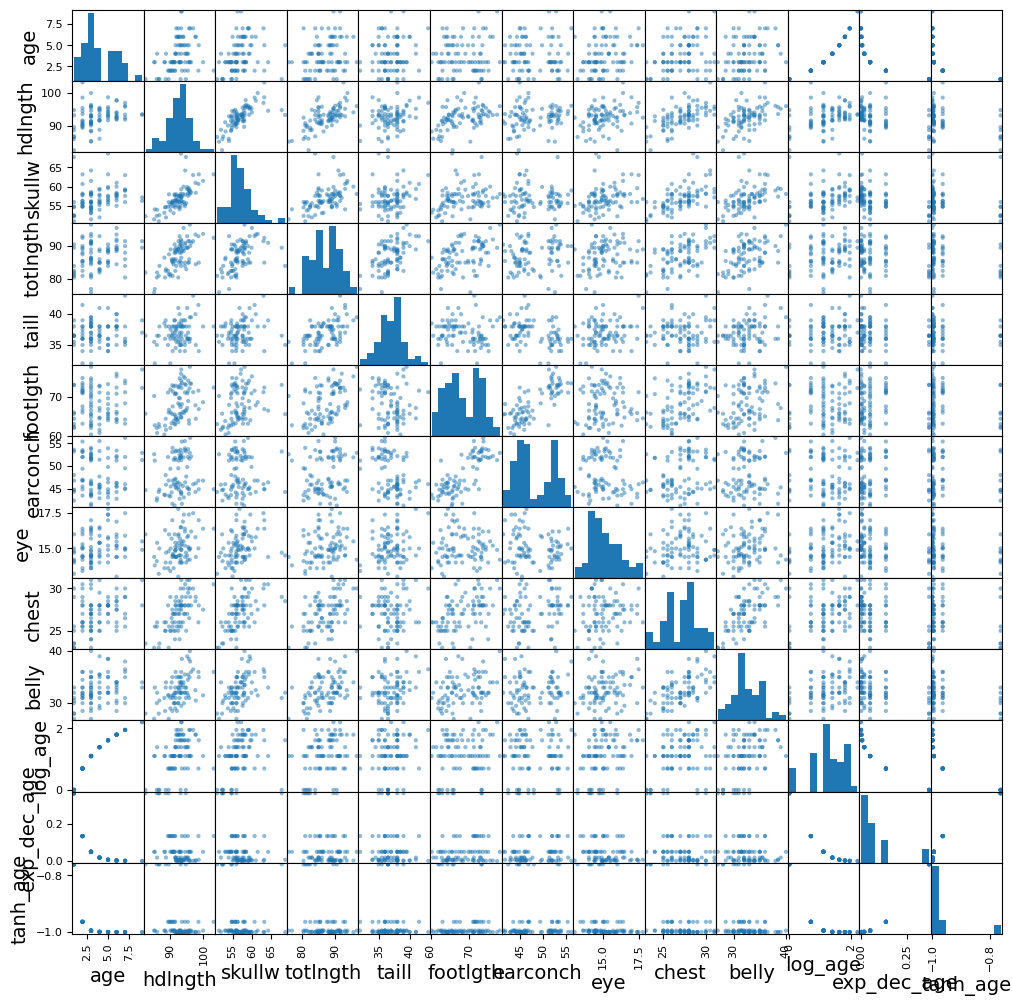

In [70]:
pd.plotting.scatter_matrix(possum_data_train_set[selected_columns], figsize=(12, 12))
plt.show()

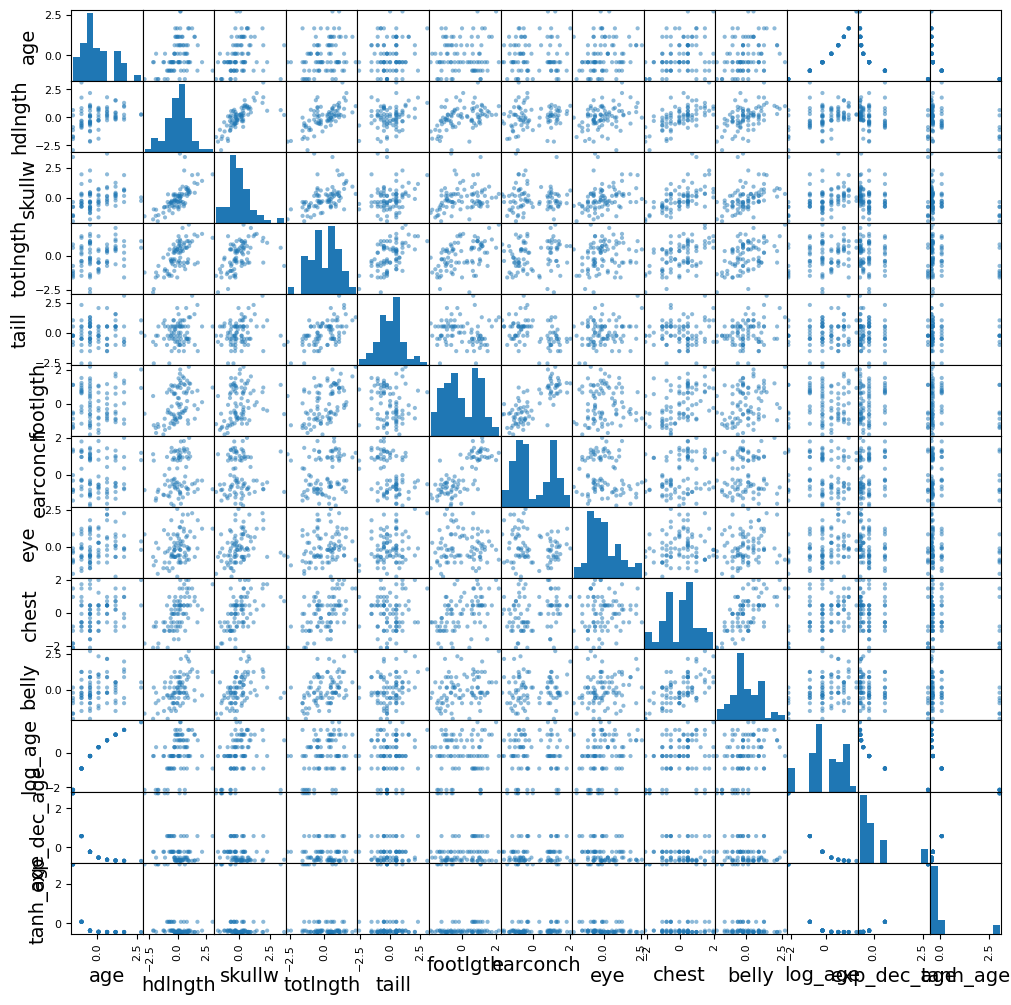

In [71]:
pd.plotting.scatter_matrix(imputed_scaled_possum_train_dataset[selected_columns], figsize=(12, 12))
plt.show()

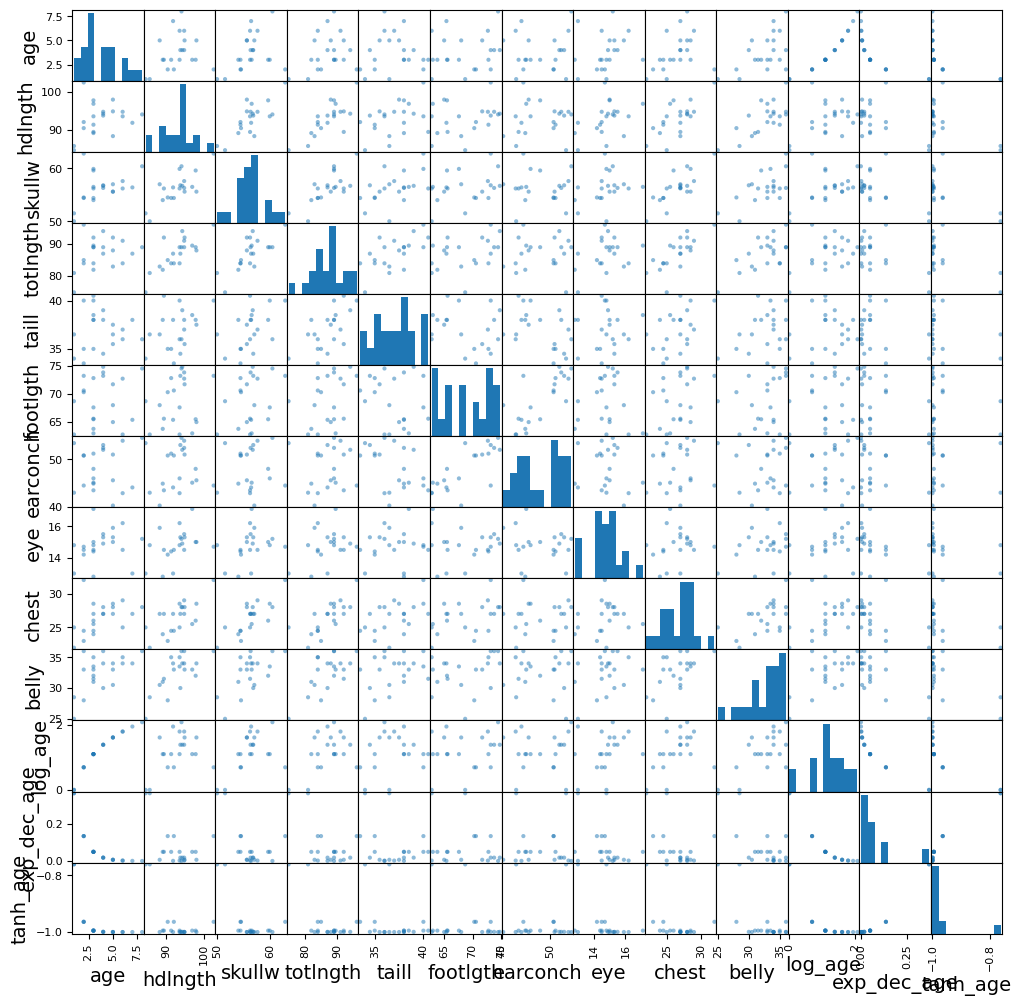

In [72]:
pd.plotting.scatter_matrix(possum_data_test_set[selected_columns], figsize=(12, 12))
plt.show()

In [73]:
possum_select_features=['skullw', 'totlngth', 'footlgth', 'chest', 'belly']
possum_data_regressor = LinearRegression().fit(imputed_scaled_possum_train_dataset[possum_select_features],
                                               imputed_scaled_possum_train_dataset["hdlngth"])

In [74]:
y_pred_train = possum_data_regressor.predict(imputed_scaled_possum_train_dataset[possum_select_features])

print(f"Test Set Mean squared error: {mean_squared_error(imputed_scaled_possum_train_dataset["hdlngth"], 
                                                         y_pred_train):.2f}")
print(f"Test Set Root Mean squared error: {root_mean_squared_error(imputed_scaled_possum_train_dataset["hdlngth"], 
                                                                   y_pred_train):.2f}")
print(f"Test Set Coefficient of determination: {r2_score(imputed_scaled_possum_train_dataset["hdlngth"], 
                                                         y_pred_train):.2f}")

Test Set Mean squared error: 0.33
Test Set Root Mean squared error: 0.57
Test Set Coefficient of determination: 0.67


In [75]:
y_pred_train = possum_data_regressor.predict(imputed_scaled_possum_test_dataset[possum_select_features])

print(f"Test Set Mean squared error: {mean_squared_error(imputed_scaled_possum_test_dataset["hdlngth"], 
                                                         y_pred_train):.2f}")
print(f"Test Set Root Mean squared error: {root_mean_squared_error(imputed_scaled_possum_test_dataset["hdlngth"], 
                                                                   y_pred_train):.2f}")
print(f"Test Set Coefficient of determination: {r2_score(imputed_scaled_possum_test_dataset["hdlngth"], 
                                                         y_pred_train):.2f}")

Test Set Mean squared error: 0.32
Test Set Root Mean squared error: 0.56
Test Set Coefficient of determination: 0.68


<Axes: >

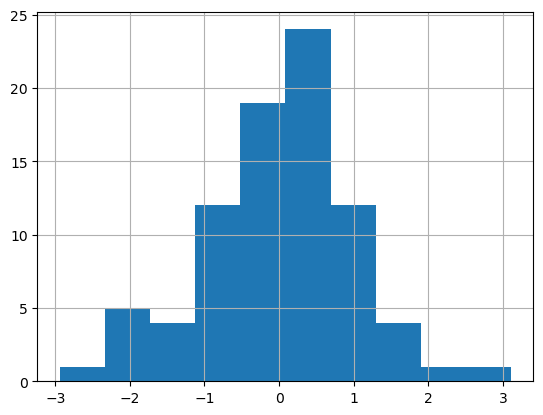

In [76]:
imputed_scaled_possum_train_dataset["hdlngth"].hist()

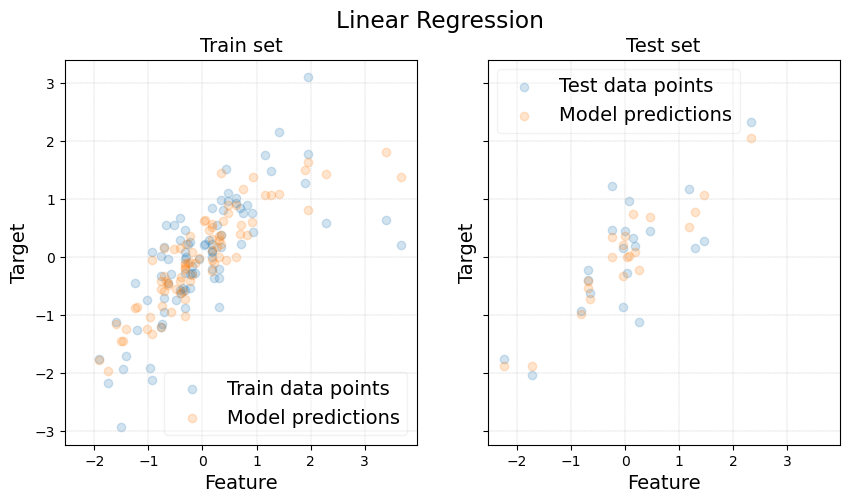

In [77]:
fig, ax = plt.subplots(ncols=2, figsize=(10, 5), sharex=True, sharey=True)
ax[0].grid(linestyle='--', linewidth=0.25)
ax[0].scatter(imputed_scaled_possum_train_dataset['skullw'].values, 
              imputed_scaled_possum_train_dataset['hdlngth'], 
              label="Train data points",
              alpha=0.2)
ax[0].scatter(imputed_scaled_possum_train_dataset['skullw'].values, 
              possum_data_regressor.predict(imputed_scaled_possum_train_dataset[possum_select_features]),  
              label="Model predictions",
              alpha=0.2
             )
ax[0].set(xlabel="Feature", ylabel="Target", title="Train set")
ax[0].legend(loc='best', framealpha=0.25)

ax[1].grid(linestyle='--', linewidth=0.25)
ax[1].scatter(imputed_scaled_possum_test_dataset['skullw'].values, 
              imputed_scaled_possum_test_dataset['hdlngth'], 
              label="Test data points",
              alpha=0.2
             )
ax[1].scatter(imputed_scaled_possum_test_dataset['skullw'].values, 
              possum_data_regressor.predict(imputed_scaled_possum_test_dataset[possum_select_features]), 
              label="Model predictions",
              alpha=0.2)
ax[1].set(xlabel="Feature", ylabel="Target", title="Test set")
ax[1].legend(loc='best', framealpha=0.25)

fig.suptitle("Linear Regression")

plt.show()

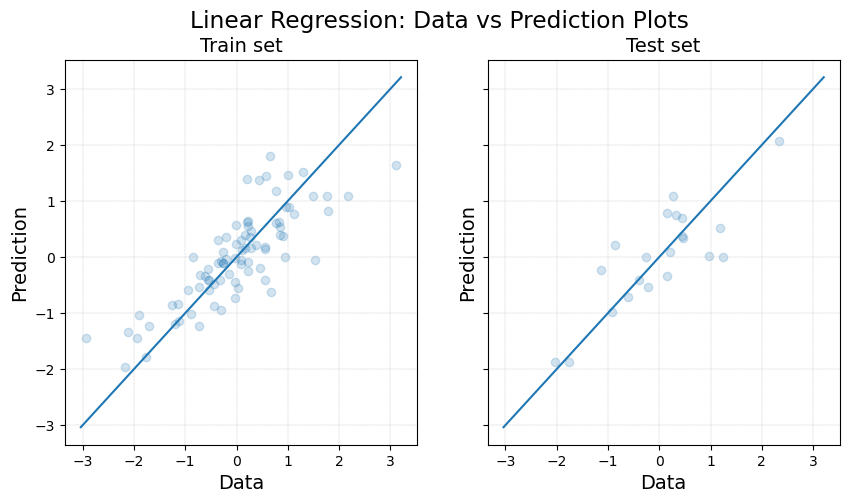

In [78]:
fig, ax = plt.subplots(ncols=2, figsize=(10, 5), sharex=True, sharey=True)
ax[0].grid(linestyle='--', linewidth=0.25)
ax[0].plot(np.linspace(np.min(imputed_scaled_possum_train_dataset['hdlngth'].values)-0.1,
                       np.max(imputed_scaled_possum_train_dataset['hdlngth'].values)+0.1, 
                       num=20),
           np.linspace(np.min(imputed_scaled_possum_train_dataset['hdlngth'].values)-0.1,
                       np.max(imputed_scaled_possum_train_dataset['hdlngth'].values)+0.1, 
                       num=20)
          )
ax[0].scatter(imputed_scaled_possum_train_dataset['hdlngth'].values, 
              possum_data_regressor.predict(imputed_scaled_possum_train_dataset[possum_select_features]),  
              alpha=0.2
             )
ax[0].set(xlabel="Data", ylabel="Prediction", title="Train set")

ax[1].grid(linestyle='--', linewidth=0.25)
ax[1].plot(np.linspace(np.min(imputed_scaled_possum_train_dataset['hdlngth'].values)-0.1,
                       np.max(imputed_scaled_possum_train_dataset['hdlngth'].values)+0.1, 
                       num=20),
           np.linspace(np.min(imputed_scaled_possum_train_dataset['hdlngth'].values)-0.1,
                       np.max(imputed_scaled_possum_train_dataset['hdlngth'].values)+0.1, 
                       num=20)
          )
ax[1].scatter(imputed_scaled_possum_test_dataset['hdlngth'].values, 
              possum_data_regressor.predict(imputed_scaled_possum_test_dataset[possum_select_features]), 
              alpha=0.2)
ax[1].set(xlabel="Data", ylabel="Prediction", title="Test set")

fig.suptitle("Linear Regression: Data vs Prediction Plots")

plt.show()

<Axes: >

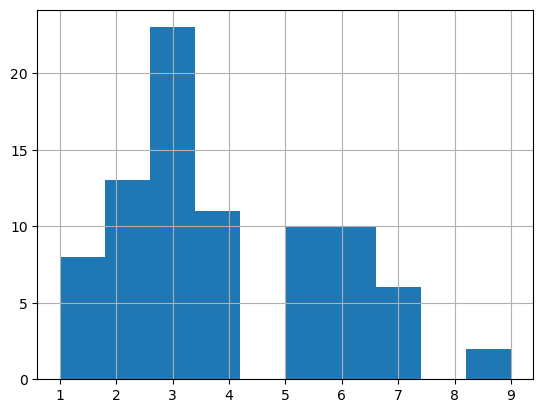

In [79]:
possum_data_train_set.age.hist()

<Axes: >

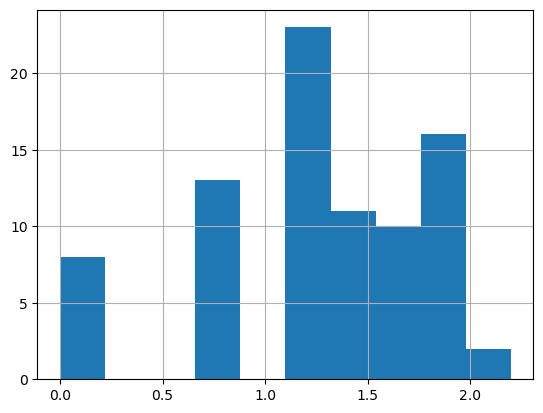

In [80]:
np.log(possum_data_train_set.age).hist()

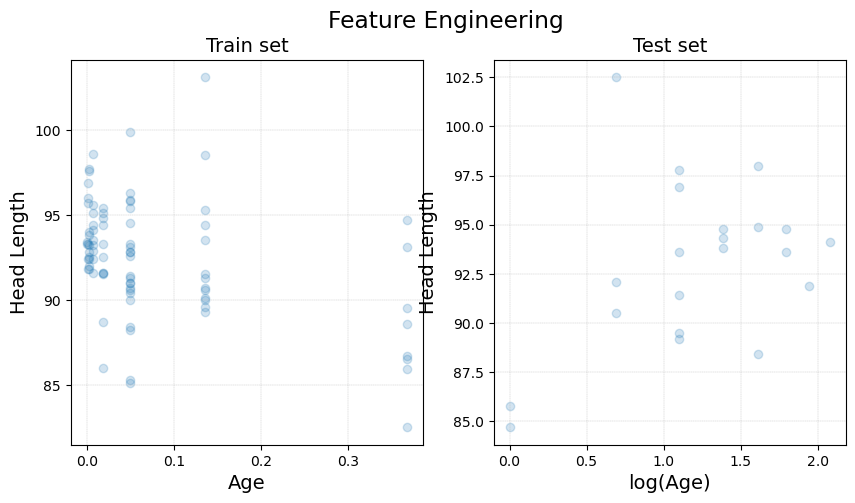

In [81]:
fig, ax = plt.subplots(ncols=2, figsize=(10, 5))
ax[0].grid(linestyle='--', linewidth=0.25)
ax[0].scatter(np.exp(-possum_data_train_set['age']).values, 
              possum_data_train_set['hdlngth'], 
              alpha=0.2)
ax[0].set(xlabel="Age", ylabel="Head Length", title="Train set")

ax[1].grid(linestyle='--', linewidth=0.25)
ax[1].scatter(np.log(possum_data_test_set['age'].values), 
              possum_data_test_set['hdlngth'], 
              alpha=0.2
             )
ax[1].set(xlabel="log(Age)", ylabel="Head Length", title="Test set")

fig.suptitle("Feature Engineering")

plt.show()

In [82]:
possum_data_train_set.corr()["hdlngth"]

case          -0.257771
site          -0.220273
age            0.339946
hdlngth        1.000000
skullw         0.714051
totlngth       0.660886
taill          0.256227
footlgth       0.429558
earconch       0.140141
eye            0.339005
chest          0.627838
belly          0.519990
log_age        0.386841
exp_dec_age   -0.392980
tanh_age      -0.390001
Name: hdlngth, dtype: float64

---
* Checking if log(age) added as a feature helps in better prediction
---

In [83]:
possum_select_features=['skullw', 'totlngth', 'footlgth', 'chest', 'belly', 'log_age']
possum_data_regressor = LinearRegression().fit(imputed_scaled_possum_train_dataset[possum_select_features],
                                               imputed_scaled_possum_train_dataset["hdlngth"])

In [84]:
y_pred_train = possum_data_regressor.predict(imputed_scaled_possum_train_dataset[possum_select_features])

print(f"Test Set Mean squared error: {mean_squared_error(imputed_scaled_possum_train_dataset["hdlngth"], 
                                                         y_pred_train):.2f}")
print(f"Test Set Root Mean squared error: {root_mean_squared_error(imputed_scaled_possum_train_dataset["hdlngth"], 
                                                                   y_pred_train):.2f}")
print(f"Test Set Coefficient of determination: {r2_score(imputed_scaled_possum_train_dataset["hdlngth"], 
                                                         y_pred_train):.2f}")

Test Set Mean squared error: 0.31
Test Set Root Mean squared error: 0.56
Test Set Coefficient of determination: 0.69


In [85]:
y_pred_train = possum_data_regressor.predict(imputed_scaled_possum_test_dataset[possum_select_features])

print(f"Test Set Mean squared error: {mean_squared_error(imputed_scaled_possum_test_dataset["hdlngth"], 
                                                         y_pred_train):.2f}")
print(f"Test Set Root Mean squared error: {root_mean_squared_error(imputed_scaled_possum_test_dataset["hdlngth"], 
                                                                   y_pred_train):.2f}")
print(f"Test Set Coefficient of determination: {r2_score(imputed_scaled_possum_test_dataset["hdlngth"], 
                                                         y_pred_train):.2f}")

Test Set Mean squared error: 0.35
Test Set Root Mean squared error: 0.59
Test Set Coefficient of determination: 0.65


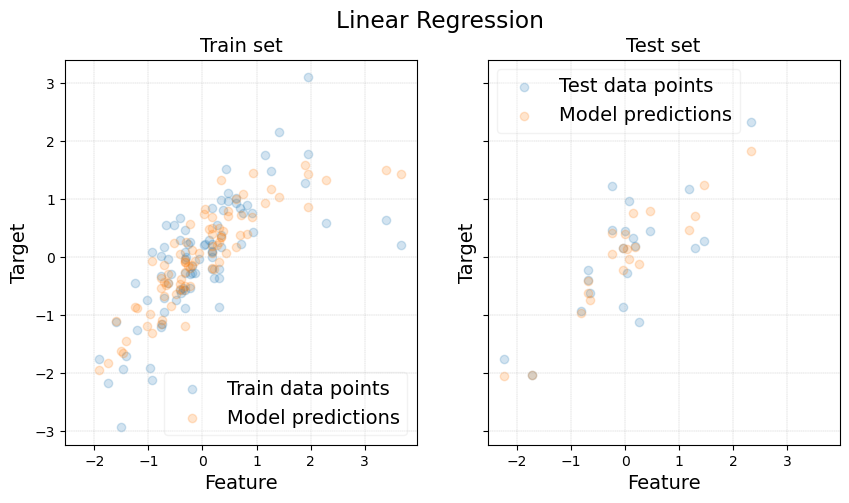

In [86]:
fig, ax = plt.subplots(ncols=2, figsize=(10, 5), sharex=True, sharey=True)
ax[0].grid(linestyle='--', linewidth=0.25)
ax[0].scatter(imputed_scaled_possum_train_dataset['skullw'].values, 
              imputed_scaled_possum_train_dataset['hdlngth'], 
              label="Train data points",
              alpha=0.2)
ax[0].scatter(imputed_scaled_possum_train_dataset['skullw'].values, 
              possum_data_regressor.predict(imputed_scaled_possum_train_dataset[possum_select_features]),  
              label="Model predictions",
              alpha=0.2
             )
ax[0].set(xlabel="Feature", ylabel="Target", title="Train set")
ax[0].legend(loc='best', framealpha=0.25)

ax[1].grid(linestyle='--', linewidth=0.25)
ax[1].scatter(imputed_scaled_possum_test_dataset['skullw'].values, 
              imputed_scaled_possum_test_dataset['hdlngth'], 
              label="Test data points",
              alpha=0.2
             )
ax[1].scatter(imputed_scaled_possum_test_dataset['skullw'].values, 
              possum_data_regressor.predict(imputed_scaled_possum_test_dataset[possum_select_features]), 
              label="Model predictions",
              alpha=0.2)
ax[1].set(xlabel="Feature", ylabel="Target", title="Test set")
ax[1].legend(loc='best', framealpha=0.25)

fig.suptitle("Linear Regression")

plt.show()

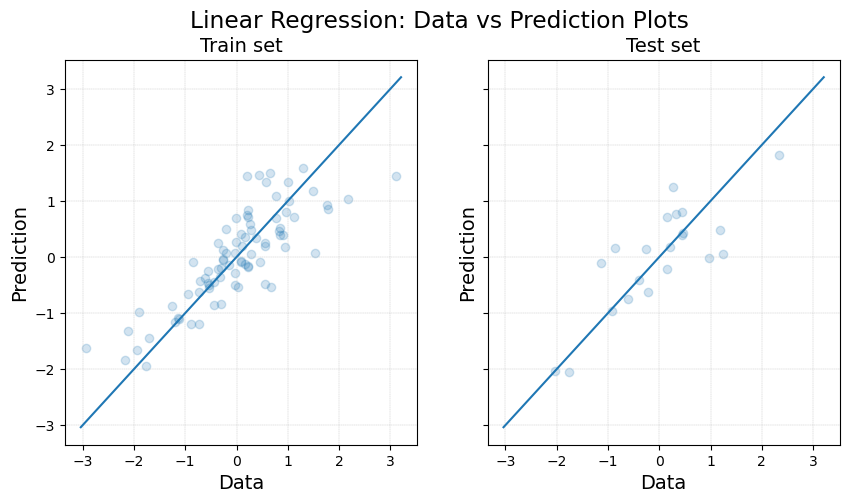

In [87]:
fig, ax = plt.subplots(ncols=2, figsize=(10, 5), sharex=True, sharey=True)
ax[0].grid(linestyle='--', linewidth=0.25)
ax[0].plot(np.linspace(np.min(imputed_scaled_possum_train_dataset['hdlngth'].values)-0.1,
                       np.max(imputed_scaled_possum_train_dataset['hdlngth'].values)+0.1, 
                       num=20),
           np.linspace(np.min(imputed_scaled_possum_train_dataset['hdlngth'].values)-0.1,
                       np.max(imputed_scaled_possum_train_dataset['hdlngth'].values)+0.1, 
                       num=20)
          )
ax[0].scatter(imputed_scaled_possum_train_dataset['hdlngth'].values, 
              possum_data_regressor.predict(imputed_scaled_possum_train_dataset[possum_select_features]),  
              alpha=0.2
             )
ax[0].set(xlabel="Data", ylabel="Prediction", title="Train set")

ax[1].grid(linestyle='--', linewidth=0.25)
ax[1].plot(np.linspace(np.min(imputed_scaled_possum_train_dataset['hdlngth'].values)-0.1,
                       np.max(imputed_scaled_possum_train_dataset['hdlngth'].values)+0.1, 
                       num=20),
           np.linspace(np.min(imputed_scaled_possum_train_dataset['hdlngth'].values)-0.1,
                       np.max(imputed_scaled_possum_train_dataset['hdlngth'].values)+0.1, 
                       num=20)
          )
ax[1].scatter(imputed_scaled_possum_test_dataset['hdlngth'].values, 
              possum_data_regressor.predict(imputed_scaled_possum_test_dataset[possum_select_features]), 
              alpha=0.2)
ax[1].set(xlabel="Data", ylabel="Prediction", title="Test set")

fig.suptitle("Linear Regression: Data vs Prediction Plots")

plt.show()

---
* Checking if exp(-age) added as a feature helps in better prediction
---

In [88]:
possum_select_features=['skullw', 'totlngth', 'footlgth', 'chest', 'belly', 'exp_dec_age']
possum_data_regressor = LinearRegression().fit(imputed_scaled_possum_train_dataset[possum_select_features],
                                               imputed_scaled_possum_train_dataset["hdlngth"])

In [89]:
y_pred_train = possum_data_regressor.predict(imputed_scaled_possum_train_dataset[possum_select_features])

print(f"Test Set Mean squared error: {mean_squared_error(imputed_scaled_possum_train_dataset["hdlngth"], 
                                                         y_pred_train):.2f}")
print(f"Test Set Root Mean squared error: {root_mean_squared_error(imputed_scaled_possum_train_dataset["hdlngth"], 
                                                                   y_pred_train):.2f}")
print(f"Test Set Coefficient of determination: {r2_score(imputed_scaled_possum_train_dataset["hdlngth"], 
                                                         y_pred_train):.2f}")

Test Set Mean squared error: 0.30
Test Set Root Mean squared error: 0.55
Test Set Coefficient of determination: 0.70


In [90]:
y_pred_train = possum_data_regressor.predict(imputed_scaled_possum_test_dataset[possum_select_features])

print(f"Test Set Mean squared error: {mean_squared_error(imputed_scaled_possum_test_dataset["hdlngth"], 
                                                         y_pred_train):.2f}")
print(f"Test Set Root Mean squared error: {root_mean_squared_error(imputed_scaled_possum_test_dataset["hdlngth"], 
                                                                   y_pred_train):.2f}")
print(f"Test Set Coefficient of determination: {r2_score(imputed_scaled_possum_test_dataset["hdlngth"], 
                                                         y_pred_train):.2f}")

Test Set Mean squared error: 0.35
Test Set Root Mean squared error: 0.59
Test Set Coefficient of determination: 0.65


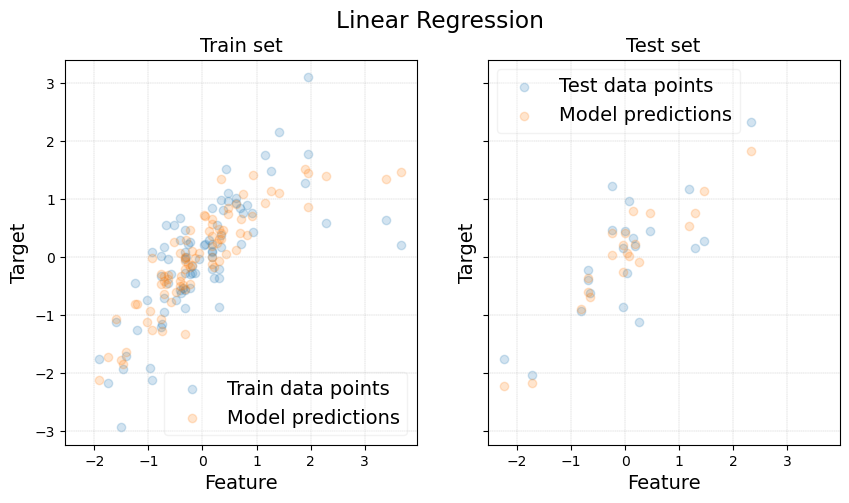

In [91]:
fig, ax = plt.subplots(ncols=2, figsize=(10, 5), sharex=True, sharey=True)
ax[0].grid(linestyle='--', linewidth=0.25)
ax[0].scatter(imputed_scaled_possum_train_dataset['skullw'].values, 
              imputed_scaled_possum_train_dataset['hdlngth'], 
              label="Train data points",
              alpha=0.2)
ax[0].scatter(imputed_scaled_possum_train_dataset['skullw'].values, 
              possum_data_regressor.predict(imputed_scaled_possum_train_dataset[possum_select_features]),  
              label="Model predictions",
              alpha=0.2
             )
ax[0].set(xlabel="Feature", ylabel="Target", title="Train set")
ax[0].legend(loc='best', framealpha=0.25)

ax[1].grid(linestyle='--', linewidth=0.25)
ax[1].scatter(imputed_scaled_possum_test_dataset['skullw'].values, 
              imputed_scaled_possum_test_dataset['hdlngth'], 
              label="Test data points",
              alpha=0.2
             )
ax[1].scatter(imputed_scaled_possum_test_dataset['skullw'].values, 
              possum_data_regressor.predict(imputed_scaled_possum_test_dataset[possum_select_features]), 
              label="Model predictions",
              alpha=0.2)
ax[1].set(xlabel="Feature", ylabel="Target", title="Test set")
ax[1].legend(loc='best', framealpha=0.25)

fig.suptitle("Linear Regression")

plt.show()

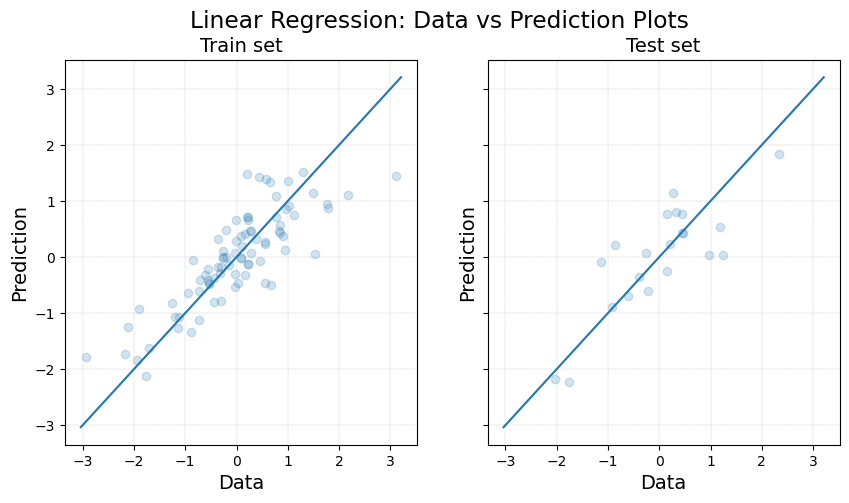

In [92]:
fig, ax = plt.subplots(ncols=2, figsize=(10, 5), sharex=True, sharey=True)
ax[0].grid(linestyle='--', linewidth=0.25)
ax[0].plot(np.linspace(np.min(imputed_scaled_possum_train_dataset['hdlngth'].values)-0.1,
                       np.max(imputed_scaled_possum_train_dataset['hdlngth'].values)+0.1, 
                       num=20),
           np.linspace(np.min(imputed_scaled_possum_train_dataset['hdlngth'].values)-0.1,
                       np.max(imputed_scaled_possum_train_dataset['hdlngth'].values)+0.1, 
                       num=20)
          )
ax[0].scatter(imputed_scaled_possum_train_dataset['hdlngth'].values, 
              possum_data_regressor.predict(imputed_scaled_possum_train_dataset[possum_select_features]),  
              alpha=0.2
             )
ax[0].set(xlabel="Data", ylabel="Prediction", title="Train set")

ax[1].grid(linestyle='--', linewidth=0.25)
ax[1].plot(np.linspace(np.min(imputed_scaled_possum_train_dataset['hdlngth'].values)-0.1,
                       np.max(imputed_scaled_possum_train_dataset['hdlngth'].values)+0.1, 
                       num=20),
           np.linspace(np.min(imputed_scaled_possum_train_dataset['hdlngth'].values)-0.1,
                       np.max(imputed_scaled_possum_train_dataset['hdlngth'].values)+0.1, 
                       num=20)
          )
ax[1].scatter(imputed_scaled_possum_test_dataset['hdlngth'].values, 
              possum_data_regressor.predict(imputed_scaled_possum_test_dataset[possum_select_features]), 
              alpha=0.2)
ax[1].set(xlabel="Data", ylabel="Prediction", title="Test set")

fig.suptitle("Linear Regression: Data vs Prediction Plots")

plt.show()

---
* Add all numerical features 
---

In [93]:
possum_select_features=['skullw', 'totlngth', 'taill',
       'footlgth', 'earconch', 'eye', 'chest', 'belly', 
       'exp_dec_age']
possum_data_regressor = LinearRegression().fit(imputed_scaled_possum_train_dataset[possum_select_features],
                                               imputed_scaled_possum_train_dataset["hdlngth"])

In [94]:
y_pred_train = possum_data_regressor.predict(imputed_scaled_possum_train_dataset[possum_select_features])

print(f"Test Set Mean squared error: {mean_squared_error(imputed_scaled_possum_train_dataset["hdlngth"], 
                                                         y_pred_train):.2f}")
print(f"Test Set Root Mean squared error: {root_mean_squared_error(imputed_scaled_possum_train_dataset["hdlngth"], 
                                                                   y_pred_train):.2f}")
print(f"Test Set Coefficient of determination: {r2_score(imputed_scaled_possum_train_dataset["hdlngth"], 
                                                         y_pred_train):.2f}")

Test Set Mean squared error: 0.30
Test Set Root Mean squared error: 0.54
Test Set Coefficient of determination: 0.70


In [95]:
y_pred_train = possum_data_regressor.predict(imputed_scaled_possum_test_dataset[possum_select_features])

print(f"Test Set Mean squared error: {mean_squared_error(imputed_scaled_possum_test_dataset["hdlngth"], 
                                                         y_pred_train):.2f}")
print(f"Test Set Root Mean squared error: {root_mean_squared_error(imputed_scaled_possum_test_dataset["hdlngth"], 
                                                                   y_pred_train):.2f}")
print(f"Test Set Coefficient of determination: {r2_score(imputed_scaled_possum_test_dataset["hdlngth"], 
                                                         y_pred_train):.2f}")

Test Set Mean squared error: 0.34
Test Set Root Mean squared error: 0.58
Test Set Coefficient of determination: 0.66


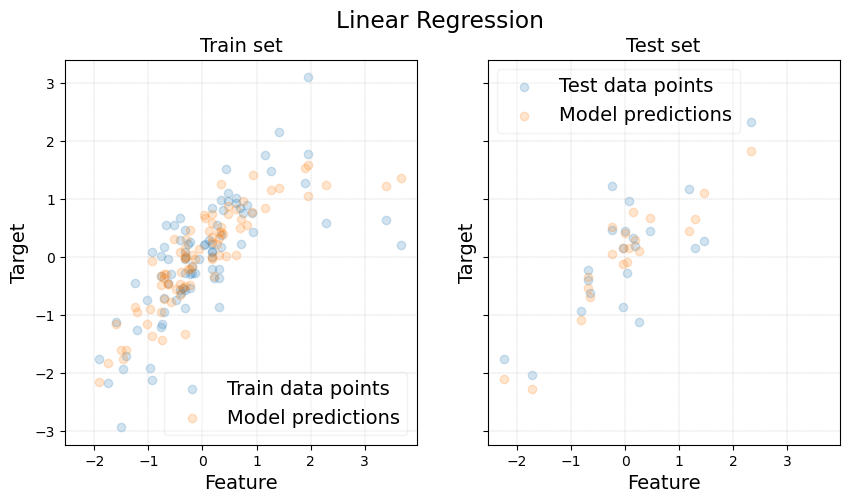

In [96]:
fig, ax = plt.subplots(ncols=2, figsize=(10, 5), sharex=True, sharey=True)
ax[0].grid(linestyle='--', linewidth=0.25)
ax[0].scatter(imputed_scaled_possum_train_dataset['skullw'].values, 
              imputed_scaled_possum_train_dataset['hdlngth'], 
              label="Train data points",
              alpha=0.2)
ax[0].scatter(imputed_scaled_possum_train_dataset['skullw'].values, 
              possum_data_regressor.predict(imputed_scaled_possum_train_dataset[possum_select_features]),  
              label="Model predictions",
              alpha=0.2
             )
ax[0].set(xlabel="Feature", ylabel="Target", title="Train set")
ax[0].legend(loc='best', framealpha=0.25)

ax[1].grid(linestyle='--', linewidth=0.25)
ax[1].scatter(imputed_scaled_possum_test_dataset['skullw'].values, 
              imputed_scaled_possum_test_dataset['hdlngth'], 
              label="Test data points",
              alpha=0.2
             )
ax[1].scatter(imputed_scaled_possum_test_dataset['skullw'].values, 
              possum_data_regressor.predict(imputed_scaled_possum_test_dataset[possum_select_features]), 
              label="Model predictions",
              alpha=0.2)
ax[1].set(xlabel="Feature", ylabel="Target", title="Test set")
ax[1].legend(loc='best', framealpha=0.25)

fig.suptitle("Linear Regression")

plt.show()

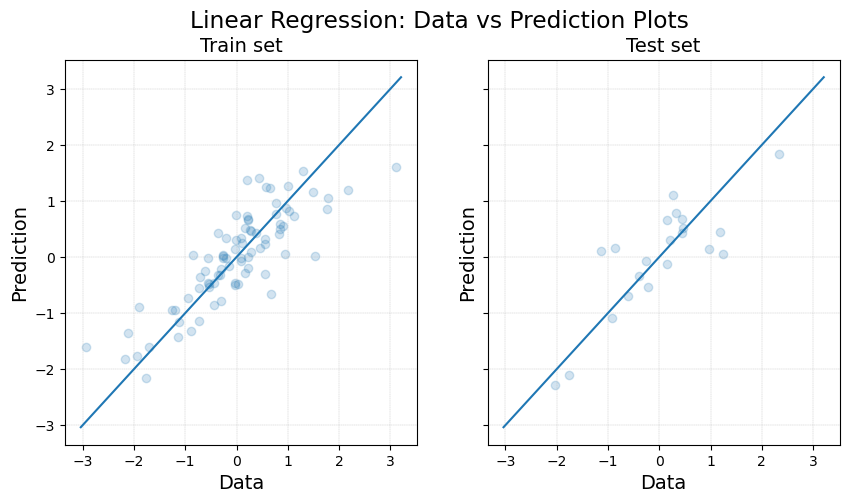

In [97]:
fig, ax = plt.subplots(ncols=2, figsize=(10, 5), sharex=True, sharey=True)
ax[0].grid(linestyle='--', linewidth=0.25)
ax[0].plot(np.linspace(np.min(imputed_scaled_possum_train_dataset['hdlngth'].values)-0.1,
                       np.max(imputed_scaled_possum_train_dataset['hdlngth'].values)+0.1, 
                       num=20),
           np.linspace(np.min(imputed_scaled_possum_train_dataset['hdlngth'].values)-0.1,
                       np.max(imputed_scaled_possum_train_dataset['hdlngth'].values)+0.1, 
                       num=20)
          )
ax[0].scatter(imputed_scaled_possum_train_dataset['hdlngth'].values, 
              possum_data_regressor.predict(imputed_scaled_possum_train_dataset[possum_select_features]),  
              alpha=0.2
             )
ax[0].set(xlabel="Data", ylabel="Prediction", title="Train set")

ax[1].grid(linestyle='--', linewidth=0.25)
ax[1].plot(np.linspace(np.min(imputed_scaled_possum_train_dataset['hdlngth'].values)-0.1,
                       np.max(imputed_scaled_possum_train_dataset['hdlngth'].values)+0.1, 
                       num=20),
           np.linspace(np.min(imputed_scaled_possum_train_dataset['hdlngth'].values)-0.1,
                       np.max(imputed_scaled_possum_train_dataset['hdlngth'].values)+0.1, 
                       num=20)
          )
ax[1].scatter(imputed_scaled_possum_test_dataset['hdlngth'].values, 
              possum_data_regressor.predict(imputed_scaled_possum_test_dataset[possum_select_features]), 
              alpha=0.2)
ax[1].set(xlabel="Data", ylabel="Prediction", title="Test set")

fig.suptitle("Linear Regression: Data vs Prediction Plots")

plt.show()

---
* Polynomial regression of order 2, 4 and 8
* First with limited set of features
---

In [98]:
from sklearn.preprocessing import PolynomialFeatures

In [99]:
# Transform features to polynomial features of degree 2
quadratic_model = PolynomialFeatures(degree=2, include_bias=False)
cubic_model = PolynomialFeatures(degree=3, include_bias=False)
fourth_order_model = PolynomialFeatures(degree=4, include_bias=False)
eighth_order_model = PolynomialFeatures(degree=8, include_bias=False)

In [100]:
possum_select_features=['skullw', 'totlngth', 'footlgth', 'chest', 'belly', 'exp_dec_age']
imputed_scaled_possum_train_dataset[possum_select_features]

,skullw,totlngth,footlgth,chest,belly,exp_dec_age
0,-0.644089,-0.616049,1.009301,-0.064486,-0.952656,-0.229692
1,0.466343,0.942855,1.168261,0.445263,1.243746,-0.229692
2,-0.326823,-0.256302,1.054718,0.445263,-0.220522,-0.527521
3,1.894042,1.062771,0.668672,1.464762,1.426779,-0.692221
4,-0.295096,0.463193,1.009301,0.445263,0.877679,-0.527521
...,...,...,...,...,...,...
78,-0.929629,-2.414785,-1.284267,-0.829111,0.145545,-0.229692
79,0.180804,-0.735965,-0.943638,0.955013,0.877679,-0.692221
80,-0.770996,0.463193,0.555129,-1.593735,-0.952656,-0.229692
81,-0.707542,0.822940,1.100135,1.464762,-0.220522,2.780567


In [101]:
X_train_quadratic = quadratic_model.fit_transform(imputed_scaled_possum_train_dataset[possum_select_features])
X_test_quadratic = quadratic_model.fit_transform(imputed_scaled_possum_test_dataset[possum_select_features])

In [102]:
X_train_quadratic

array([[-0.64408896, -0.61604893,  1.00930108, ...,  0.9075542 ,
         0.21881741,  0.05275835],
       [ 0.46634334,  0.94285537,  1.16826121, ...,  1.54690372,
        -0.28567829,  0.05275835],
       [-0.32682259, -0.25630178,  1.05471826, ...,  0.04863009,
         0.11633012,  0.27827827],
       ...,
       [-0.77099551,  0.46319251,  0.55512927, ...,  0.9075542 ,
         0.21881741,  0.05275835],
       [-0.70754224,  0.82293966,  1.10013544, ...,  0.04863009,
        -0.613177  ,  7.73155112],
       [ 0.62497653, -0.25630178, -1.19343218, ...,  0.34408707,
         0.40604938,  0.47916971]], shape=(83, 27))

In [103]:
X_train_cubic = cubic_model.fit_transform(imputed_scaled_possum_train_dataset[possum_select_features])
X_test_cubic = cubic_model.fit_transform(imputed_scaled_possum_test_dataset[possum_select_features])

In [104]:
X_train_cubic

array([[-6.44088962e-01, -6.16048928e-01,  1.00930108e+00, ...,
        -2.08457807e-01, -5.02605773e-02, -1.21181628e-02],
       [ 4.66343343e-01,  9.42855372e-01,  1.16826121e+00, ...,
        -3.55311184e-01,  6.56179759e-02, -1.21181628e-02],
       [-3.26822589e-01, -2.56301782e-01,  1.05471826e+00, ...,
        -2.56533878e-02, -6.13665681e-02, -1.46797597e-01],
       ...,
       [-7.70995511e-01,  4.63192510e-01,  5.55129273e-01, ...,
        -2.08457807e-01, -5.02605773e-02, -1.21181628e-02],
       [-7.07542237e-01,  8.22939656e-01,  1.10013544e+00, ...,
         1.35219209e-01, -1.70497953e+00,  2.14980935e+01],
       [ 6.24976530e-01, -2.56301782e-01, -1.19343218e+00, ...,
        -2.38184244e-01, -2.81075851e-01, -3.31691268e-01]],
      shape=(83, 83))

In [105]:
X_train_fourth = fourth_order_model.fit_transform(imputed_scaled_possum_train_dataset[possum_select_features])
X_test_fourth = fourth_order_model.fit_transform(imputed_scaled_possum_test_dataset[possum_select_features])

In [106]:
X_test_fourth

array([[-2.51403457e-01,  1.02093872e+00,  6.91675767e-01, ...,
         1.12338266e-02, -4.15663053e-02,  1.53799573e-01],
       [ 6.96455522e-02,  4.92866967e-01, -1.41799306e+00, ...,
         1.33767647e-03, -1.70795522e-03,  2.18072988e-03],
       [ 1.46085792e+00,  3.87252617e-01,  1.37064964e+00, ...,
         7.20952261e-01, -4.01018022e-01,  2.23059782e-01],
       ...,
       [-3.73707841e-02,  1.02093872e+00, -7.87517318e-01, ...,
         6.18340949e-03,  3.67210373e-03,  2.18072988e-03],
       [-2.51403457e-01,  1.76023917e-01, -9.33011719e-01, ...,
         1.07957074e-01, -1.28855546e-01,  1.53799573e-01],
       [ 1.76661888e-01, -3.52047833e-02,  1.05541177e+00, ...,
         2.14185277e-01,  1.23192007e-01,  7.08558068e-02]],
      shape=(21, 209))

In [107]:
X_train_eighth = eighth_order_model.fit_transform(imputed_scaled_possum_train_dataset[possum_select_features])
X_test_eighth = eighth_order_model.fit_transform(imputed_scaled_possum_test_dataset[possum_select_features])

In [108]:
X_test_eighth

array([[-2.51403457e-01,  1.02093872e+00,  6.91675767e-01, ...,
         1.72775774e-03, -6.39288001e-03,  2.36543087e-02],
       [ 6.96455522e-02,  4.92866967e-01, -1.41799306e+00, ...,
         2.91711105e-06, -3.72458899e-06,  4.75558280e-06],
       [ 1.46085792e+00,  3.87252617e-01,  1.37064964e+00, ...,
         1.60815454e-01, -8.94509925e-02,  4.97556663e-02],
       ...,
       [-3.73707841e-02,  1.02093872e+00, -7.87517318e-01, ...,
         1.34843458e-05,  8.00786632e-06,  4.75558280e-06],
       [-2.51403457e-01,  1.76023917e-01, -9.33011719e-01, ...,
         1.66037518e-02, -1.98179280e-02,  2.36543087e-02],
       [ 1.76661888e-01, -3.52047833e-02,  1.05541177e+00, ...,
         1.51762706e-02,  8.72886906e-03,  5.02054536e-03]],
      shape=(21, 3002))

In [109]:
possum_data_regressor = LinearRegression().fit(imputed_scaled_possum_train_dataset[possum_select_features],
                                               imputed_scaled_possum_train_dataset["hdlngth"])

In [110]:
possum_data_regressor_quad = LinearRegression().fit(X_train_quadratic,
                                                    imputed_scaled_possum_train_dataset["hdlngth"])

In [111]:
possum_data_regressor_cubic = LinearRegression().fit(X_train_cubic,
                                                    imputed_scaled_possum_train_dataset["hdlngth"])

In [112]:
possum_data_regressor_fourth = LinearRegression().fit(X_train_fourth,
                                                    imputed_scaled_possum_train_dataset["hdlngth"])

In [113]:
possum_data_regressor_eighth = LinearRegression().fit(X_train_eighth,
                                                    imputed_scaled_possum_train_dataset["hdlngth"])

In [114]:
y_pred_train = possum_data_regressor.predict(imputed_scaled_possum_train_dataset[possum_select_features])
y_pred_train_quad = possum_data_regressor_quad.predict(X_train_quadratic)
y_pred_train_cubic = possum_data_regressor_cubic.predict(X_train_cubic)
y_pred_train_fourth = possum_data_regressor_fourth.predict(X_train_fourth)
y_pred_train_eighth = possum_data_regressor_eighth.predict(X_train_eighth)

print(f"Train Set Mean squared error Linear: {mean_squared_error(imputed_scaled_possum_train_dataset["hdlngth"], 
                                                         y_pred_train):.2f}")
print(f"Train Set Mean squared error Quadratic: {mean_squared_error(imputed_scaled_possum_train_dataset["hdlngth"], 
                                                         y_pred_train_quad):.2f}")
print(f"Train Set Mean squared error Cubic: {mean_squared_error(imputed_scaled_possum_train_dataset["hdlngth"], 
                                                         y_pred_train_cubic):.2f}")
print(f"Train Set Mean squared error Fourth Order: {mean_squared_error(imputed_scaled_possum_train_dataset["hdlngth"], 
                                                         y_pred_train_fourth):.2f}")
print(f"Train Set Mean squared error Eighth Order: {mean_squared_error(imputed_scaled_possum_train_dataset["hdlngth"], 
                                                         y_pred_train_eighth):.2f}")
print(f"Train Set Root Mean squared error: {root_mean_squared_error(imputed_scaled_possum_train_dataset["hdlngth"], 
                                                                   y_pred_train):.2f}")
print(f"Train Set Root Mean squared error Quadratic: {root_mean_squared_error(imputed_scaled_possum_train_dataset["hdlngth"], 
                                                         y_pred_train_quad):.2f}")
print(f"Train Set Root Mean squared error Cubic: {root_mean_squared_error(imputed_scaled_possum_train_dataset["hdlngth"], 
                                                         y_pred_train_cubic):.2f}")
print(f"Train Set Root Mean squared error Fourth Order: {root_mean_squared_error(imputed_scaled_possum_train_dataset["hdlngth"], 
                                                         y_pred_train_fourth):.2f}")
print(f"Train Set Root Mean squared error Eighth Order: {root_mean_squared_error(imputed_scaled_possum_train_dataset["hdlngth"], 
                                                         y_pred_train_eighth):.2f}")
print(f"Train Set Coefficient of determination Linear: {r2_score(imputed_scaled_possum_train_dataset["hdlngth"], 
                                                         y_pred_train):.2f}")
print(f"Train Set Coefficient of determination Quadratic: {r2_score(imputed_scaled_possum_train_dataset["hdlngth"], 
                                                         y_pred_train_quad):.2f}")
print(f"Train Set Coefficient of determination Cubic: {r2_score(imputed_scaled_possum_train_dataset["hdlngth"], 
                                                         y_pred_train_cubic):.2f}")
print(f"Train Set Coefficient of determination Fourth Order: {r2_score(imputed_scaled_possum_train_dataset["hdlngth"], 
                                                         y_pred_train_fourth):.2f}")
print(f"Train Set Coefficient of determination Eighth Order: {r2_score(imputed_scaled_possum_train_dataset["hdlngth"], 
                                                         y_pred_train_eighth):.2f}")

Train Set Mean squared error Linear: 0.30
Train Set Mean squared error Quadratic: 0.21
Train Set Mean squared error Cubic: 0.00
Train Set Mean squared error Fourth Order: 0.00
Train Set Mean squared error Eighth Order: 0.00
Train Set Root Mean squared error: 0.55
Train Set Root Mean squared error Quadratic: 0.46
Train Set Root Mean squared error Cubic: 0.00
Train Set Root Mean squared error Fourth Order: 0.00
Train Set Root Mean squared error Eighth Order: 0.00
Train Set Coefficient of determination Linear: 0.70
Train Set Coefficient of determination Quadratic: 0.79
Train Set Coefficient of determination Cubic: 1.00
Train Set Coefficient of determination Fourth Order: 1.00
Train Set Coefficient of determination Eighth Order: 1.00


In [115]:
y_pred_test = possum_data_regressor.predict(imputed_scaled_possum_test_dataset[possum_select_features])
y_pred_test_quad = possum_data_regressor_quad.predict(X_test_quadratic)
y_pred_test_cubic = possum_data_regressor_cubic.predict(X_test_cubic)
y_pred_test_fourth = possum_data_regressor_fourth.predict(X_test_fourth)
y_pred_test_eighth = possum_data_regressor_eighth.predict(X_test_eighth)

print(f"Test Set Mean squared error Linear: {mean_squared_error(imputed_scaled_possum_test_dataset["hdlngth"], 
                                                         y_pred_test):.2f}")
print(f"Test Set Mean squared error Quadratic: {mean_squared_error(imputed_scaled_possum_test_dataset["hdlngth"], 
                                                         y_pred_test_quad):.2f}")
print(f"Test Set Mean squared error Cubic: {mean_squared_error(imputed_scaled_possum_test_dataset["hdlngth"], 
                                                         y_pred_test_cubic):.2f}")
print(f"Test Set Mean squared error Fourth Order: {mean_squared_error(imputed_scaled_possum_test_dataset["hdlngth"], 
                                                         y_pred_test_fourth):.2f}")
print(f"Test Set Mean squared error Eighth Order: {mean_squared_error(imputed_scaled_possum_test_dataset["hdlngth"], 
                                                         y_pred_test_eighth):.2f}")
print(f"Test Set Root Mean squared error: {root_mean_squared_error(imputed_scaled_possum_test_dataset["hdlngth"], 
                                                                   y_pred_test):.2f}")
print(f"Test Set Root Mean squared error Quadratic: {root_mean_squared_error(imputed_scaled_possum_test_dataset["hdlngth"], 
                                                         y_pred_test_quad):.2f}")
print(f"Test Set Root Mean squared error Cubic: {root_mean_squared_error(imputed_scaled_possum_test_dataset["hdlngth"], 
                                                         y_pred_test_cubic):.2f}")
print(f"Test Set Root Mean squared error Fourth Order: {root_mean_squared_error(imputed_scaled_possum_test_dataset["hdlngth"], 
                                                         y_pred_test_fourth):.2f}")
print(f"Test Set Root Mean squared error Eighth Order: {root_mean_squared_error(imputed_scaled_possum_test_dataset["hdlngth"], 
                                                         y_pred_test_eighth):.2f}")
print(f"Test Set Coefficient of determination Linear: {r2_score(imputed_scaled_possum_test_dataset["hdlngth"], 
                                                         y_pred_test):.2f}")
print(f"Test Set Coefficient of determination Quadratic: {r2_score(imputed_scaled_possum_test_dataset["hdlngth"], 
                                                         y_pred_test_quad):.2f}")
print(f"Test Set Coefficient of determination Cubic: {r2_score(imputed_scaled_possum_test_dataset["hdlngth"], 
                                                         y_pred_test_cubic):.2f}")
print(f"Test Set Coefficient of determination Fourth Order: {r2_score(imputed_scaled_possum_test_dataset["hdlngth"], 
                                                         y_pred_test_fourth):.2f}")
print(f"Test Set Coefficient of determination Eighth Order: {r2_score(imputed_scaled_possum_test_dataset["hdlngth"], 
                                                         y_pred_test_eighth):.2f}")

Test Set Mean squared error Linear: 0.35
Test Set Mean squared error Quadratic: 0.50
Test Set Mean squared error Cubic: 26.05
Test Set Mean squared error Fourth Order: 35.29
Test Set Mean squared error Eighth Order: 11286.28
Test Set Root Mean squared error: 0.59
Test Set Root Mean squared error Quadratic: 0.71
Test Set Root Mean squared error Cubic: 5.10
Test Set Root Mean squared error Fourth Order: 5.94
Test Set Root Mean squared error Eighth Order: 106.24
Test Set Coefficient of determination Linear: 0.65
Test Set Coefficient of determination Quadratic: 0.50
Test Set Coefficient of determination Cubic: -25.05
Test Set Coefficient of determination Fourth Order: -34.29
Test Set Coefficient of determination Eighth Order: -11285.28


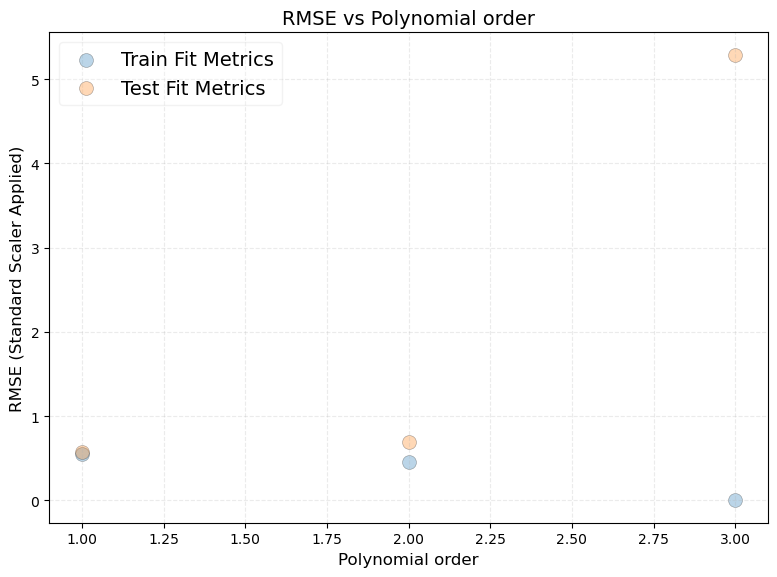

In [116]:
plt.figure(figsize=(8, 6)) # Adjust figure size as needed
plt.scatter([1, 2, 3], 
            [0.55, 0.46, 0.], 
            s=100, 
            label="Train Fit Metrics",
            alpha=0.3, 
            edgecolors='black', 
            linewidths=0.5)
plt.scatter([1, 2, 3], 
            [0.57, 0.69, 5.29], 
            s=100,
            label="Test Fit Metrics",
            alpha=0.3, 
            edgecolors='black', 
            linewidths=0.5)
plt.xlabel("Polynomial order", fontsize=12)
plt.ylabel("RMSE (Standard Scaler Applied)", fontsize=12)
plt.title("RMSE vs Polynomial order", fontsize=14)
plt.grid(True, linestyle='--', alpha=0.25)
plt.legend(loc='best', framealpha=0.25)
plt.tight_layout()  # Adjust layout to prevent labels from overlapping
plt.show()


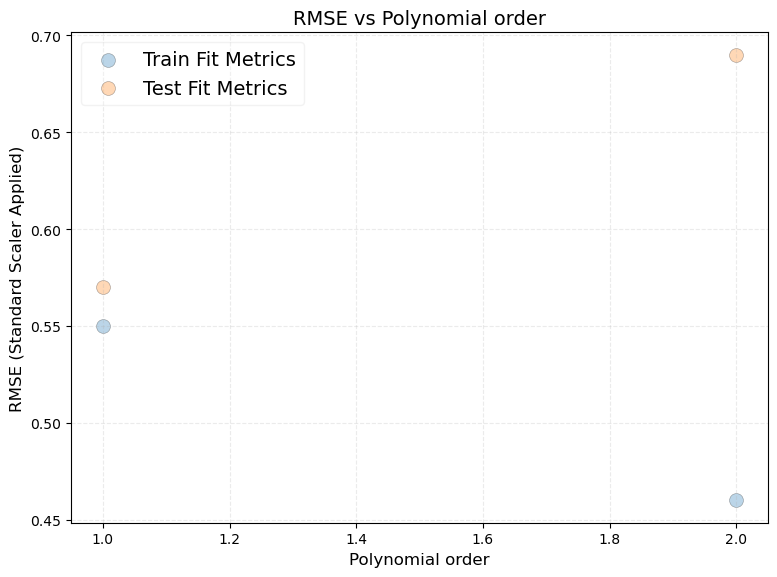

In [117]:
plt.figure(figsize=(8, 6)) # Adjust figure size as needed
plt.scatter([1, 2], 
            [0.55, 0.46], 
            s=100, 
            label="Train Fit Metrics",
            alpha=0.3, 
            edgecolors='black', 
            linewidths=0.5)
plt.scatter([1, 2], 
            [0.57, 0.69], 
            s=100,
            label="Test Fit Metrics",
            alpha=0.3, 
            edgecolors='black', 
            linewidths=0.5)
plt.xlabel("Polynomial order", fontsize=12)
plt.ylabel("RMSE (Standard Scaler Applied)", fontsize=12)
plt.title("RMSE vs Polynomial order", fontsize=14)
plt.grid(True, linestyle='--', alpha=0.25)
plt.legend(loc='best', framealpha=0.25)
plt.tight_layout()  # Adjust layout to prevent labels from overlapping
plt.show()

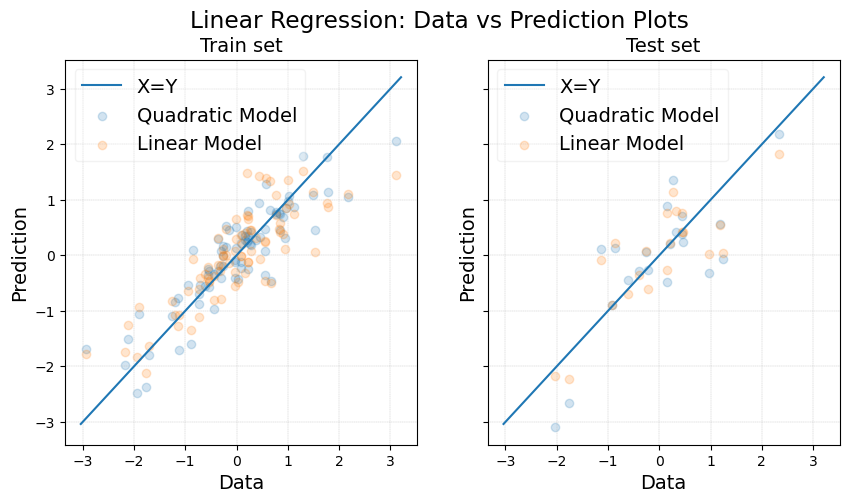

In [118]:
fig, ax = plt.subplots(ncols=2, figsize=(10, 5), sharex=True, sharey=True)
ax[0].grid(linestyle='--', linewidth=0.25)
ax[0].plot(np.linspace(np.min(imputed_scaled_possum_train_dataset['hdlngth'].values)-0.1,
                       np.max(imputed_scaled_possum_train_dataset['hdlngth'].values)+0.1, 
                       num=20),
           np.linspace(np.min(imputed_scaled_possum_train_dataset['hdlngth'].values)-0.1,
                       np.max(imputed_scaled_possum_train_dataset['hdlngth'].values)+0.1, 
                       num=20),
           label="X=Y",
          )
ax[0].scatter(imputed_scaled_possum_train_dataset['hdlngth'].values, 
              possum_data_regressor_quad.predict(X_train_quadratic),  
              alpha=0.2,
              label="Quadratic Model",
             )
ax[0].scatter(imputed_scaled_possum_train_dataset['hdlngth'].values, 
              possum_data_regressor.predict(imputed_scaled_possum_train_dataset[possum_select_features]),  
              alpha=0.2,
              label="Linear Model",
             )
ax[0].set(xlabel="Data", ylabel="Prediction", title="Train set")
ax[0].legend(loc='best', framealpha=0.25)

ax[1].grid(linestyle='--', linewidth=0.25)
ax[1].plot(np.linspace(np.min(imputed_scaled_possum_train_dataset['hdlngth'].values)-0.1,
                       np.max(imputed_scaled_possum_train_dataset['hdlngth'].values)+0.1, 
                       num=20),
           np.linspace(np.min(imputed_scaled_possum_train_dataset['hdlngth'].values)-0.1,
                       np.max(imputed_scaled_possum_train_dataset['hdlngth'].values)+0.1, 
                       num=20),
           label="X=Y",
          )
ax[1].scatter(imputed_scaled_possum_test_dataset['hdlngth'].values, 
              possum_data_regressor_quad.predict(X_test_quadratic),  
              alpha=0.2,
              label="Quadratic Model",
             )
ax[1].scatter(imputed_scaled_possum_test_dataset['hdlngth'].values, 
              possum_data_regressor.predict(imputed_scaled_possum_test_dataset[possum_select_features]), 
              alpha=0.2,
              label="Linear Model",
             )
ax[1].set(xlabel="Data", ylabel="Prediction", title="Test set")
ax[1].legend(loc='best', framealpha=0.25)

fig.suptitle("Linear Regression: Data vs Prediction Plots")

plt.show()

* Try Decision Tree (White Box Model)

In [119]:
from sklearn.tree import DecisionTreeRegressor

tree_reg = DecisionTreeRegressor(random_state=42)
tree_reg.fit(imputed_scaled_possum_train_dataset[possum_select_features],
             imputed_scaled_possum_train_dataset["hdlngth"])

DecisionTreeRegressor(random_state=42)

In [120]:
y_pred_train = tree_reg.predict(imputed_scaled_possum_train_dataset[possum_select_features])

print(f"Test Set Mean squared error: {mean_squared_error(imputed_scaled_possum_train_dataset["hdlngth"], 
                                                         y_pred_train):.2f}")
print(f"Test Set Root Mean squared error: {root_mean_squared_error(imputed_scaled_possum_train_dataset["hdlngth"], 
                                                                   y_pred_train):.2f}")
print(f"Test Set Coefficient of determination: {r2_score(imputed_scaled_possum_train_dataset["hdlngth"], 
                                                         y_pred_train):.2f}")

Test Set Mean squared error: 0.00
Test Set Root Mean squared error: 0.00
Test Set Coefficient of determination: 1.00


In [121]:
y_pred_test = tree_reg.predict(imputed_scaled_possum_test_dataset[possum_select_features])

print(f"Test Set Mean squared error: {mean_squared_error(imputed_scaled_possum_test_dataset["hdlngth"], 
                                                         y_pred_test):.2f}")
print(f"Test Set Root Mean squared error: {root_mean_squared_error(imputed_scaled_possum_test_dataset["hdlngth"], 
                                                                   y_pred_test):.2f}")
print(f"Test Set Coefficient of determination: {r2_score(imputed_scaled_possum_test_dataset["hdlngth"], 
                                                         y_pred_test):.2f}")

Test Set Mean squared error: 1.15
Test Set Root Mean squared error: 1.07
Test Set Coefficient of determination: -0.15


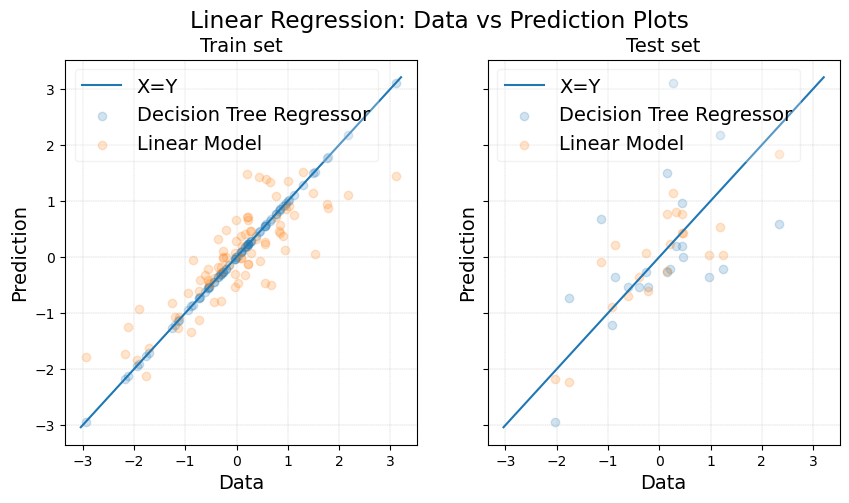

In [122]:
fig, ax = plt.subplots(ncols=2, figsize=(10, 5), sharex=True, sharey=True)
ax[0].grid(linestyle='--', linewidth=0.25)
ax[0].plot(np.linspace(np.min(imputed_scaled_possum_train_dataset['hdlngth'].values)-0.1,
                       np.max(imputed_scaled_possum_train_dataset['hdlngth'].values)+0.1, 
                       num=20),
           np.linspace(np.min(imputed_scaled_possum_train_dataset['hdlngth'].values)-0.1,
                       np.max(imputed_scaled_possum_train_dataset['hdlngth'].values)+0.1, 
                       num=20),
           label="X=Y",
          )
ax[0].scatter(imputed_scaled_possum_train_dataset['hdlngth'].values, 
              y_pred_train,  
              alpha=0.2,
              label="Decision Tree Regressor",
             )
ax[0].scatter(imputed_scaled_possum_train_dataset['hdlngth'].values, 
              possum_data_regressor.predict(imputed_scaled_possum_train_dataset[possum_select_features]),  
              alpha=0.2,
              label="Linear Model",
             )
ax[0].set(xlabel="Data", ylabel="Prediction", title="Train set")
ax[0].legend(loc='best', framealpha=0.25)

ax[1].grid(linestyle='--', linewidth=0.25)
ax[1].plot(np.linspace(np.min(imputed_scaled_possum_train_dataset['hdlngth'].values)-0.1,
                       np.max(imputed_scaled_possum_train_dataset['hdlngth'].values)+0.1, 
                       num=20),
           np.linspace(np.min(imputed_scaled_possum_train_dataset['hdlngth'].values)-0.1,
                       np.max(imputed_scaled_possum_train_dataset['hdlngth'].values)+0.1, 
                       num=20),
           label="X=Y",
          )
ax[1].scatter(imputed_scaled_possum_test_dataset['hdlngth'].values, 
              y_pred_test,  
              alpha=0.2,
              label="Decision Tree Regressor",
             )
ax[1].scatter(imputed_scaled_possum_test_dataset['hdlngth'].values, 
              possum_data_regressor.predict(imputed_scaled_possum_test_dataset[possum_select_features]), 
              alpha=0.2,
              label="Linear Model",
             )
ax[1].set(xlabel="Data", ylabel="Prediction", title="Test set")
ax[1].legend(loc='best', framealpha=0.25)

fig.suptitle("Linear Regression: Data vs Prediction Plots")

plt.show()

* Try cross validation

In [123]:
from sklearn.model_selection import cross_val_score

In [124]:
tree_rmses = -cross_val_score(tree_reg, 
                              imputed_scaled_possum_train_dataset[possum_select_features],
                              imputed_scaled_possum_train_dataset["hdlngth"],
                              scoring="neg_root_mean_squared_error", cv=10)

In [125]:
pd.Series(tree_rmses).describe()

count    10.000000
mean      0.668724
std       0.233777
min       0.372861
25%       0.458544
50%       0.667509
75%       0.799251
max       1.075224
dtype: float64

<Axes: >

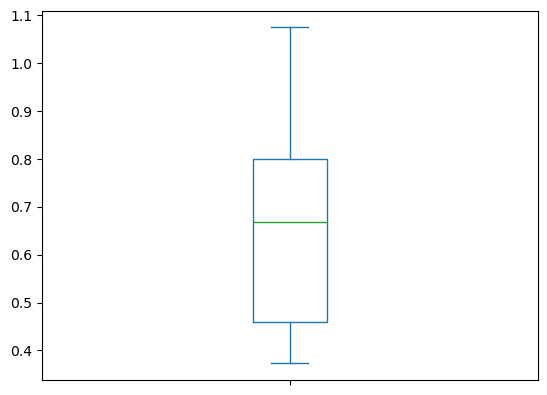

In [126]:
pd.Series(tree_rmses).plot.box()

In [127]:
lin_rmses = -cross_val_score(possum_data_regressor, 
                             imputed_scaled_possum_train_dataset[possum_select_features],
                             imputed_scaled_possum_train_dataset["hdlngth"],
                             scoring="neg_root_mean_squared_error", cv=10)
pd.Series(lin_rmses).describe()

count    10.000000
mean      0.592980
std       0.146347
min       0.482592
25%       0.509990
50%       0.546211
75%       0.611416
max       0.985811
dtype: float64

In [128]:
pd.Series(lin_rmses).describe()

count    10.000000
mean      0.592980
std       0.146347
min       0.482592
25%       0.509990
50%       0.546211
75%       0.611416
max       0.985811
dtype: float64

<Axes: >

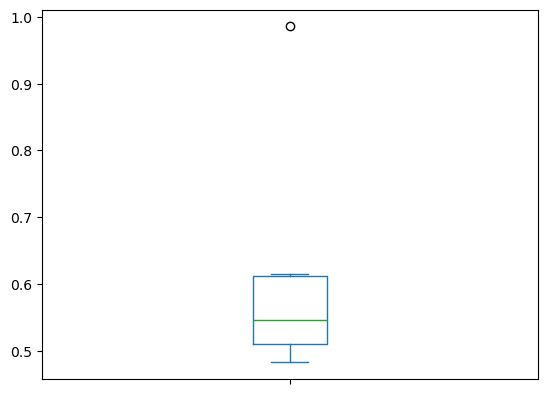

In [129]:
pd.Series(lin_rmses).plot.box()

* Try Random Forest Regressor (Black Box Model)

In [130]:
from sklearn.ensemble import RandomForestRegressor

forest_reg = RandomForestRegressor(random_state=42)
forest_rmses = -cross_val_score(forest_reg, 
                                imputed_scaled_possum_train_dataset[possum_select_features],
                                imputed_scaled_possum_train_dataset["hdlngth"],
                                scoring="neg_root_mean_squared_error", cv=10)

In [131]:
pd.Series(forest_rmses).describe()

count    10.000000
mean      0.559201
std       0.140114
min       0.356254
25%       0.473822
50%       0.532156
75%       0.586307
max       0.838749
dtype: float64

<Axes: >

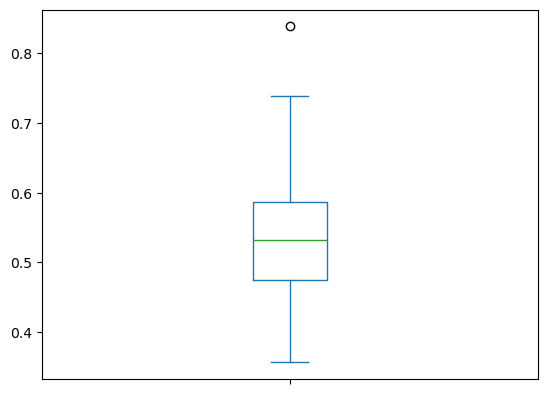

In [132]:
pd.Series(forest_rmses).plot.box()

In [133]:
forest_reg.fit(imputed_scaled_possum_train_dataset[possum_select_features],
              imputed_scaled_possum_train_dataset["hdlngth"])
rf_reg_pred_train = forest_reg.predict(imputed_scaled_possum_train_dataset[possum_select_features])

print(f"Test Set Mean squared error: {mean_squared_error(imputed_scaled_possum_train_dataset["hdlngth"], 
                                                         rf_reg_pred_train):.2f}")
print(f"Test Set Root Mean squared error: {root_mean_squared_error(imputed_scaled_possum_train_dataset["hdlngth"], 
                                                                   rf_reg_pred_train):.2f}")
print(f"Test Set Coefficient of determination: {r2_score(imputed_scaled_possum_train_dataset["hdlngth"], 
                                                         rf_reg_pred_train):.2f}")

Test Set Mean squared error: 0.05
Test Set Root Mean squared error: 0.22
Test Set Coefficient of determination: 0.95


In [134]:
rf_reg_pred_test = forest_reg.predict(imputed_scaled_possum_test_dataset[possum_select_features])

print(f"Test Set Mean squared error: {mean_squared_error(imputed_scaled_possum_test_dataset["hdlngth"], 
                                                         rf_reg_pred_test):.2f}")
print(f"Test Set Root Mean squared error: {root_mean_squared_error(imputed_scaled_possum_test_dataset["hdlngth"], 
                                                                   rf_reg_pred_test):.2f}")
print(f"Test Set Coefficient of determination: {r2_score(imputed_scaled_possum_test_dataset["hdlngth"], 
                                                         rf_reg_pred_test):.2f}")

Test Set Mean squared error: 0.45
Test Set Root Mean squared error: 0.67
Test Set Coefficient of determination: 0.55


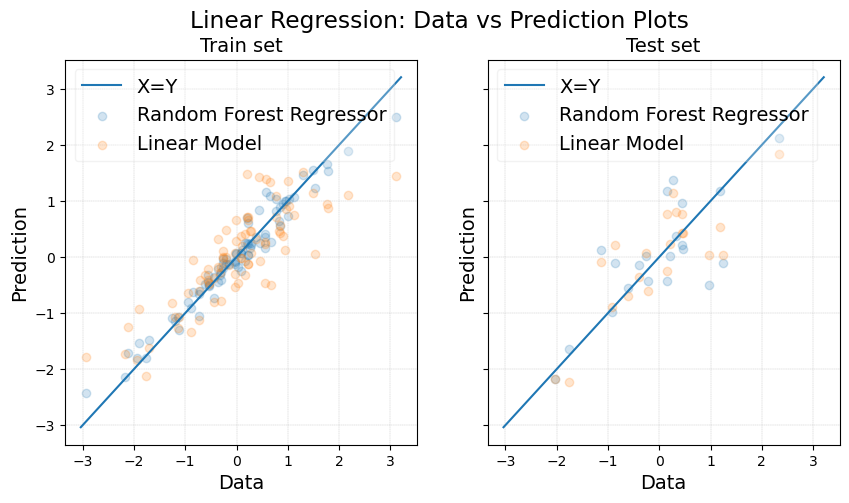

In [135]:
fig, ax = plt.subplots(ncols=2, figsize=(10, 5), sharex=True, sharey=True)
ax[0].grid(linestyle='--', linewidth=0.25)
ax[0].plot(np.linspace(np.min(imputed_scaled_possum_train_dataset['hdlngth'].values)-0.1,
                       np.max(imputed_scaled_possum_train_dataset['hdlngth'].values)+0.1, 
                       num=20),
           np.linspace(np.min(imputed_scaled_possum_train_dataset['hdlngth'].values)-0.1,
                       np.max(imputed_scaled_possum_train_dataset['hdlngth'].values)+0.1, 
                       num=20),
           label="X=Y",
          )
ax[0].scatter(imputed_scaled_possum_train_dataset['hdlngth'].values, 
              rf_reg_pred_train,  
              alpha=0.2,
              label="Random Forest Regressor",
             )
ax[0].scatter(imputed_scaled_possum_train_dataset['hdlngth'].values, 
              possum_data_regressor.predict(imputed_scaled_possum_train_dataset[possum_select_features]),  
              alpha=0.2,
              label="Linear Model",
             )
ax[0].set(xlabel="Data", ylabel="Prediction", title="Train set")
ax[0].legend(loc='best', framealpha=0.25)

ax[1].grid(linestyle='--', linewidth=0.25)
ax[1].plot(np.linspace(np.min(imputed_scaled_possum_train_dataset['hdlngth'].values)-0.1,
                       np.max(imputed_scaled_possum_train_dataset['hdlngth'].values)+0.1, 
                       num=20),
           np.linspace(np.min(imputed_scaled_possum_train_dataset['hdlngth'].values)-0.1,
                       np.max(imputed_scaled_possum_train_dataset['hdlngth'].values)+0.1, 
                       num=20),
           label="X=Y",
          )
ax[1].scatter(imputed_scaled_possum_test_dataset['hdlngth'].values, 
              rf_reg_pred_test,  
              alpha=0.2,
              label="Random Forest Regressor",
             )
ax[1].scatter(imputed_scaled_possum_test_dataset['hdlngth'].values, 
              possum_data_regressor.predict(imputed_scaled_possum_test_dataset[possum_select_features]), 
              alpha=0.2,
              label="Linear Model",
             )
ax[1].set(xlabel="Data", ylabel="Prediction", title="Test set")
ax[1].legend(loc='best', framealpha=0.25)

fig.suptitle("Linear Regression: Data vs Prediction Plots")

plt.show()

In [136]:
from sklearn.ensemble import GradientBoostingRegressor

In [137]:
gb_forest_reg = GradientBoostingRegressor(random_state=42, 
                                          max_depth=4)
gb_forest_rmses = -cross_val_score(gb_forest_reg, 
                                imputed_scaled_possum_train_dataset[possum_select_features],
                                imputed_scaled_possum_train_dataset["hdlngth"],
                                scoring="neg_root_mean_squared_error", cv=10)

In [138]:
gb_forest_reg

GradientBoostingRegressor(max_depth=4, random_state=42)

In [139]:
pd.Series(gb_forest_rmses).describe()

count    10.000000
mean      0.587142
std       0.098393
min       0.401412
25%       0.550388
50%       0.570072
75%       0.623508
max       0.777484
dtype: float64

<Axes: >

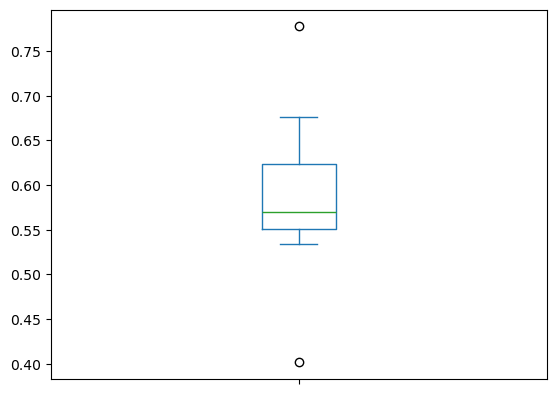

In [140]:
pd.Series(gb_forest_rmses).plot.box()

In [141]:
gb_n500_forest_reg = GradientBoostingRegressor(n_estimators=500,
                                          random_state=42, 
                                          max_depth=4)
gb_n500_forest_rmses = -cross_val_score(gb_n500_forest_reg, 
                                imputed_scaled_possum_train_dataset[possum_select_features],
                                imputed_scaled_possum_train_dataset["hdlngth"],
                                scoring="neg_root_mean_squared_error", cv=10)

In [142]:
pd.Series(gb_n500_forest_rmses).describe()

count    10.000000
mean      0.589775
std       0.100506
min       0.401165
25%       0.548341
50%       0.573502
75%       0.625781
max       0.784086
dtype: float64

<Axes: >

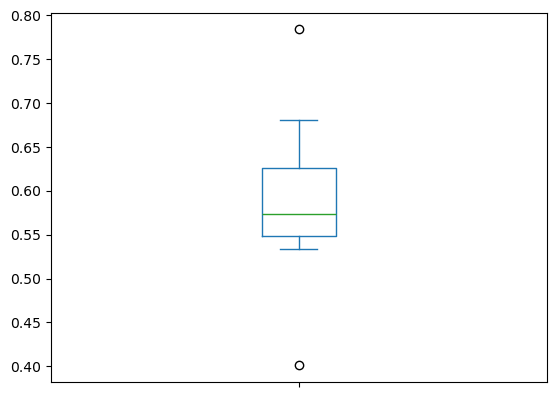

In [143]:
pd.Series(gb_n500_forest_rmses).plot.box()

In [144]:
gb_n20_forest_reg = GradientBoostingRegressor(n_estimators=20,
                                          random_state=42, 
                                          max_depth=3)
gb_n20_forest_rmses = -cross_val_score(gb_n20_forest_reg, 
                                imputed_scaled_possum_train_dataset[possum_select_features],
                                imputed_scaled_possum_train_dataset["hdlngth"],
                                scoring="neg_root_mean_squared_error", cv=10)

In [145]:
pd.Series(gb_n20_forest_rmses).describe()

count    10.000000
mean      0.588944
std       0.115888
min       0.404162
25%       0.525480
50%       0.574391
75%       0.634496
max       0.843117
dtype: float64

<Axes: >

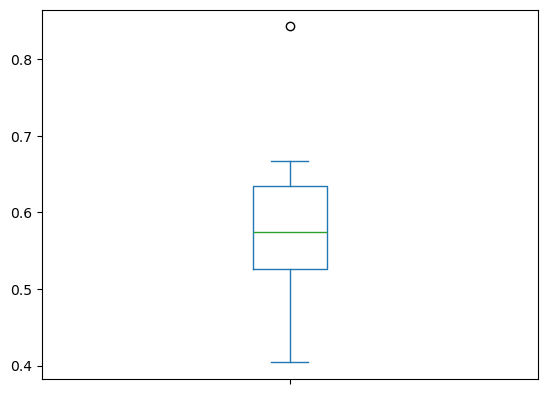

In [146]:
pd.Series(gb_n20_forest_rmses).plot.box()

In [147]:
gb_n50_forest_reg = GradientBoostingRegressor(n_estimators=50,
                                          random_state=42, 
                                          max_depth=4)
gb_n50_forest_rmses = -cross_val_score(gb_n50_forest_reg, 
                                imputed_scaled_possum_train_dataset[possum_select_features],
                                imputed_scaled_possum_train_dataset["hdlngth"],
                                scoring="neg_root_mean_squared_error", cv=10)

In [148]:
pd.Series(gb_n50_forest_rmses).describe()

count    10.000000
mean      0.578513
std       0.095566
min       0.390795
25%       0.544608
50%       0.569169
75%       0.612066
max       0.767555
dtype: float64

<Axes: >

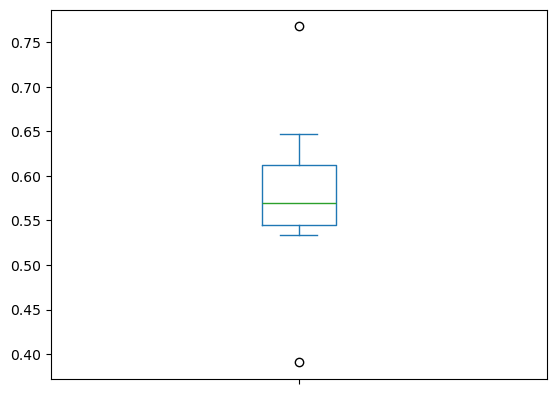

In [149]:
pd.Series(gb_n50_forest_rmses).plot.box()

In [172]:
gb_n16_forest_reg = GradientBoostingRegressor(n_estimators=16,
                                          random_state=42, 
                                          max_depth=3)
gb_n16_forest_rmses = -cross_val_score(gb_n16_forest_reg, 
                                imputed_scaled_possum_train_dataset[possum_select_features],
                                imputed_scaled_possum_train_dataset["hdlngth"],
                                scoring="neg_root_mean_squared_error", cv=10)

In [173]:
pd.Series(gb_n16_forest_rmses).describe()

count    10.000000
mean      0.597060
std       0.125520
min       0.459138
25%       0.516803
50%       0.560080
75%       0.651235
max       0.882424
dtype: float64

<Axes: >

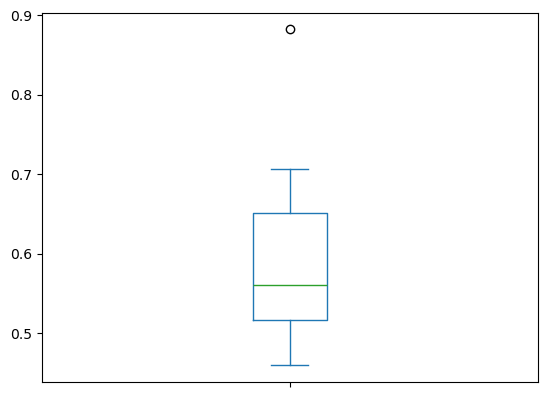

In [174]:
pd.Series(gb_n16_forest_rmses).plot.box()

In [175]:
gb_n16_forest_reg.fit(imputed_scaled_possum_train_dataset[possum_select_features],
              imputed_scaled_possum_train_dataset["hdlngth"])
gb_n16_rf_reg_pred_train = gb_n16_forest_reg.predict(imputed_scaled_possum_train_dataset[possum_select_features])

print(f"Test Set Mean squared error: {mean_squared_error(imputed_scaled_possum_train_dataset["hdlngth"], 
                                                         gb_n16_rf_reg_pred_train):.2f}")
print(f"Test Set Root Mean squared error: {root_mean_squared_error(imputed_scaled_possum_train_dataset["hdlngth"], 
                                                                   gb_n16_rf_reg_pred_train):.2f}")
print(f"Test Set Coefficient of determination: {r2_score(imputed_scaled_possum_train_dataset["hdlngth"], 
                                                         gb_n16_rf_reg_pred_train):.2f}")

Test Set Mean squared error: 0.14
Test Set Root Mean squared error: 0.37
Test Set Coefficient of determination: 0.86


In [176]:
gb_n16_rf_reg_pred_test = gb_n16_forest_reg.predict(imputed_scaled_possum_test_dataset[possum_select_features])

print(f"Test Set Mean squared error: {mean_squared_error(imputed_scaled_possum_test_dataset["hdlngth"], 
                                                         gb_n16_rf_reg_pred_test):.2f}")
print(f"Test Set Root Mean squared error: {root_mean_squared_error(imputed_scaled_possum_test_dataset["hdlngth"], 
                                                                   gb_n16_rf_reg_pred_test):.2f}")
print(f"Test Set Coefficient of determination: {r2_score(imputed_scaled_possum_test_dataset["hdlngth"], 
                                                         gb_n16_rf_reg_pred_test):.2f}")

Test Set Mean squared error: 0.45
Test Set Root Mean squared error: 0.67
Test Set Coefficient of determination: 0.55


In [178]:
gb_n16_rf_reg_pred_test = gb_n16_forest_reg.predict(imputed_scaled_possum_test_dataset[possum_select_features])

print(f"Test Set Mean squared error: {mean_squared_error(imputed_scaled_possum_test_dataset["hdlngth"], 
                                                         gb_n16_rf_reg_pred_test):.2f}")
print(f"Test Set Root Mean squared error: {root_mean_squared_error(imputed_scaled_possum_test_dataset["hdlngth"], 
                                                                   gb_n16_rf_reg_pred_test):.2f}")
print(f"Test Set Coefficient of determination: {r2_score(imputed_scaled_possum_test_dataset["hdlngth"], 
                                                         gb_n16_rf_reg_pred_test):.2f}")

Test Set Mean squared error: 0.45
Test Set Root Mean squared error: 0.67
Test Set Coefficient of determination: 0.55


In [179]:
gb_n20_forest_reg.fit(imputed_scaled_possum_train_dataset[possum_select_features],
              imputed_scaled_possum_train_dataset["hdlngth"])
gb_n20_rf_reg_pred_train = gb_n20_forest_reg.predict(imputed_scaled_possum_train_dataset[possum_select_features])

print(f"Test Set Mean squared error: {mean_squared_error(imputed_scaled_possum_train_dataset["hdlngth"], 
                                                         gb_n20_rf_reg_pred_train):.2f}")
print(f"Test Set Root Mean squared error: {root_mean_squared_error(imputed_scaled_possum_train_dataset["hdlngth"], 
                                                                   gb_n20_rf_reg_pred_train):.2f}")
print(f"Test Set Coefficient of determination: {r2_score(imputed_scaled_possum_train_dataset["hdlngth"], 
                                                         gb_n20_rf_reg_pred_train):.2f}")

Test Set Mean squared error: 0.10
Test Set Root Mean squared error: 0.32
Test Set Coefficient of determination: 0.90


In [180]:
gb_n20_rf_reg_pred_test = gb_n20_forest_reg.predict(imputed_scaled_possum_test_dataset[possum_select_features])

print(f"Test Set Mean squared error: {mean_squared_error(imputed_scaled_possum_test_dataset["hdlngth"], 
                                                         gb_n20_rf_reg_pred_test):.2f}")
print(f"Test Set Root Mean squared error: {root_mean_squared_error(imputed_scaled_possum_test_dataset["hdlngth"], 
                                                                   gb_n20_rf_reg_pred_test):.2f}")
print(f"Test Set Coefficient of determination: {r2_score(imputed_scaled_possum_test_dataset["hdlngth"], 
                                                         gb_n20_rf_reg_pred_test):.2f}")

Test Set Mean squared error: 0.43
Test Set Root Mean squared error: 0.65
Test Set Coefficient of determination: 0.57


In [181]:
gb_n50_forest_reg.fit(imputed_scaled_possum_train_dataset[possum_select_features],
              imputed_scaled_possum_train_dataset["hdlngth"])
gb_n50_rf_reg_pred_train = gb_n50_forest_reg.predict(imputed_scaled_possum_train_dataset[possum_select_features])

print(f"Test Set Mean squared error: {mean_squared_error(imputed_scaled_possum_train_dataset["hdlngth"], 
                                                         gb_n50_rf_reg_pred_train):.2f}")
print(f"Test Set Root Mean squared error: {root_mean_squared_error(imputed_scaled_possum_train_dataset["hdlngth"], 
                                                                   gb_n50_rf_reg_pred_train):.2f}")
print(f"Test Set Coefficient of determination: {r2_score(imputed_scaled_possum_train_dataset["hdlngth"], 
                                                         gb_n50_rf_reg_pred_train):.2f}")

Test Set Mean squared error: 0.01
Test Set Root Mean squared error: 0.08
Test Set Coefficient of determination: 0.99


In [182]:
gb_n50_rf_reg_pred_test = gb_n50_forest_reg.predict(imputed_scaled_possum_test_dataset[possum_select_features])

print(f"Test Set Mean squared error: {mean_squared_error(imputed_scaled_possum_test_dataset["hdlngth"], 
                                                         gb_n50_rf_reg_pred_test):.2f}")
print(f"Test Set Root Mean squared error: {root_mean_squared_error(imputed_scaled_possum_test_dataset["hdlngth"], 
                                                                   gb_n50_rf_reg_pred_test):.2f}")
print(f"Test Set Coefficient of determination: {r2_score(imputed_scaled_possum_test_dataset["hdlngth"], 
                                                         gb_n50_rf_reg_pred_test):.2f}")

Test Set Mean squared error: 0.63
Test Set Root Mean squared error: 0.79
Test Set Coefficient of determination: 0.37


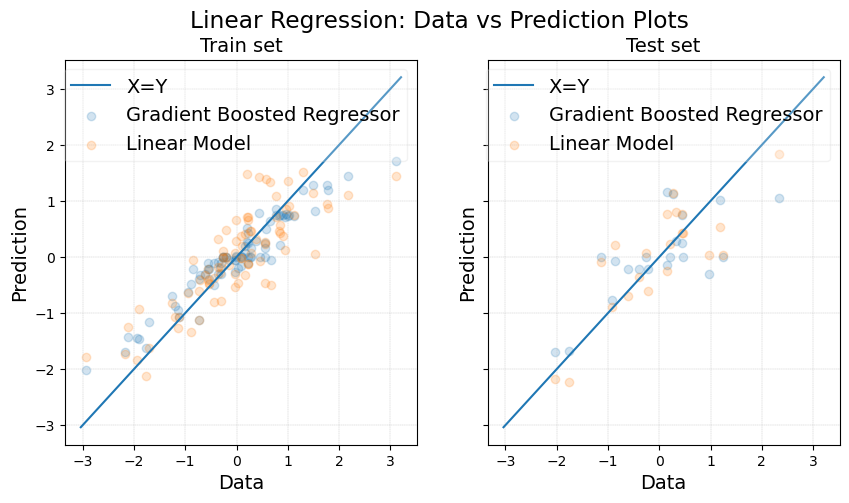

In [183]:
fig, ax = plt.subplots(ncols=2, figsize=(10, 5), sharex=True, sharey=True)
ax[0].grid(linestyle='--', linewidth=0.25)
ax[0].plot(np.linspace(np.min(imputed_scaled_possum_train_dataset['hdlngth'].values)-0.1,
                       np.max(imputed_scaled_possum_train_dataset['hdlngth'].values)+0.1, 
                       num=20),
           np.linspace(np.min(imputed_scaled_possum_train_dataset['hdlngth'].values)-0.1,
                       np.max(imputed_scaled_possum_train_dataset['hdlngth'].values)+0.1, 
                       num=20),
           label="X=Y",
          )
ax[0].scatter(imputed_scaled_possum_train_dataset['hdlngth'].values, 
              gb_n16_rf_reg_pred_train,  
              alpha=0.2,
              label="Gradient Boosted Regressor",
             )
ax[0].scatter(imputed_scaled_possum_train_dataset['hdlngth'].values, 
              possum_data_regressor.predict(imputed_scaled_possum_train_dataset[possum_select_features]),  
              alpha=0.2,
              label="Linear Model",
             )
ax[0].set(xlabel="Data", ylabel="Prediction", title="Train set")
ax[0].legend(loc='best', framealpha=0.25)

ax[1].grid(linestyle='--', linewidth=0.25)
ax[1].plot(np.linspace(np.min(imputed_scaled_possum_train_dataset['hdlngth'].values)-0.1,
                       np.max(imputed_scaled_possum_train_dataset['hdlngth'].values)+0.1, 
                       num=20),
           np.linspace(np.min(imputed_scaled_possum_train_dataset['hdlngth'].values)-0.1,
                       np.max(imputed_scaled_possum_train_dataset['hdlngth'].values)+0.1, 
                       num=20),
           label="X=Y",
          )
ax[1].scatter(imputed_scaled_possum_test_dataset['hdlngth'].values, 
              gb_n16_rf_reg_pred_test,  
              alpha=0.2,
              label="Gradient Boosted Regressor",
             )
ax[1].scatter(imputed_scaled_possum_test_dataset['hdlngth'].values, 
              possum_data_regressor.predict(imputed_scaled_possum_test_dataset[possum_select_features]), 
              alpha=0.2,
              label="Linear Model",
             )
ax[1].set(xlabel="Data", ylabel="Prediction", title="Test set")
ax[1].legend(loc='best', framealpha=0.25)

fig.suptitle("Linear Regression: Data vs Prediction Plots")

plt.show()

* Try regularization (Ridge, Lasso, Elastic Net) for regression models
    - See how good Lasso and Elastic Net are in reducing unnecessary features

In [184]:
from sklearn.linear_model import Ridge

In [185]:
ridge_regressor_alpha_10 = Ridge(alpha=10.0)

ridge_regressor_alpha_10.fit(imputed_scaled_possum_train_dataset[possum_select_features],
              imputed_scaled_possum_train_dataset["hdlngth"])

Ridge(alpha=10.0)

In [186]:
ridge_regressor_alpha_1 = Ridge(alpha=1.0)

ridge_regressor_alpha_1.fit(imputed_scaled_possum_train_dataset[possum_select_features],
              imputed_scaled_possum_train_dataset["hdlngth"])

Ridge()

In [187]:
ridge_regressor_alpha_p1 = Ridge(alpha=0.1)
ridge_regressor_alpha_p1.fit(imputed_scaled_possum_train_dataset[possum_select_features],
              imputed_scaled_possum_train_dataset["hdlngth"])

Ridge(alpha=0.1)

In [188]:
ridge_regressor_alpha_p01 = Ridge(alpha=0.01)
ridge_regressor_alpha_p01.fit(imputed_scaled_possum_train_dataset[possum_select_features],
              imputed_scaled_possum_train_dataset["hdlngth"])

Ridge(alpha=0.01)

In [189]:
ridge_regressor_alpha_1_pred_train = ridge_regressor_alpha_1.predict(imputed_scaled_possum_train_dataset[possum_select_features])

print(f"Test Set Mean squared error: {mean_squared_error(imputed_scaled_possum_train_dataset["hdlngth"], 
                                                         ridge_regressor_alpha_1_pred_train):.2f}")
print(f"Test Set Root Mean squared error: {root_mean_squared_error(imputed_scaled_possum_train_dataset["hdlngth"], 
                                                                   ridge_regressor_alpha_1_pred_train):.2f}")
print(f"Test Set Coefficient of determination: {r2_score(imputed_scaled_possum_train_dataset["hdlngth"], 
                                                         ridge_regressor_alpha_1_pred_train):.2f}")

Test Set Mean squared error: 0.30
Test Set Root Mean squared error: 0.55
Test Set Coefficient of determination: 0.70


In [190]:
ridge_regressor_alpha_1_pred_test = ridge_regressor_alpha_1.predict(imputed_scaled_possum_test_dataset[possum_select_features])

print(f"Test Set Mean squared error: {mean_squared_error(imputed_scaled_possum_test_dataset["hdlngth"], 
                                                         ridge_regressor_alpha_1_pred_test):.2f}")
print(f"Test Set Root Mean squared error: {root_mean_squared_error(imputed_scaled_possum_test_dataset["hdlngth"], 
                                                                   ridge_regressor_alpha_1_pred_test):.2f}")
print(f"Test Set Coefficient of determination: {r2_score(imputed_scaled_possum_test_dataset["hdlngth"], 
                                                         ridge_regressor_alpha_1_pred_test):.2f}")

Test Set Mean squared error: 0.35
Test Set Root Mean squared error: 0.59
Test Set Coefficient of determination: 0.65


In [191]:
ridge_regressor_alpha_1_rmses = -cross_val_score(ridge_regressor_alpha_1, 
                                imputed_scaled_possum_train_dataset[possum_select_features],
                                imputed_scaled_possum_train_dataset["hdlngth"],
                                scoring="neg_root_mean_squared_error", cv=10)
pd.Series(ridge_regressor_alpha_1_rmses).describe()

count    10.000000
mean      0.591270
std       0.145005
min       0.484888
25%       0.511815
50%       0.543239
75%       0.610063
max       0.980173
dtype: float64

<Axes: >

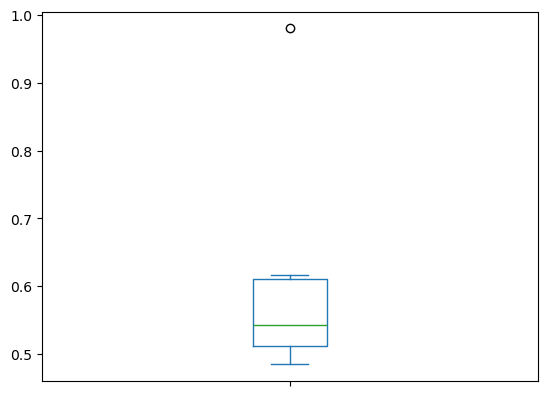

In [192]:
pd.Series(ridge_regressor_alpha_1_rmses).plot.box()

In [193]:
ridge_regressor_alpha_p1_rmses = -cross_val_score(ridge_regressor_alpha_p1, 
                                imputed_scaled_possum_train_dataset[possum_select_features],
                                imputed_scaled_possum_train_dataset["hdlngth"],
                                scoring="neg_root_mean_squared_error", cv=10)
pd.Series(ridge_regressor_alpha_p1_rmses).describe()

count    10.000000
mean      0.592798
std       0.146201
min       0.482823
25%       0.510174
50%       0.545896
75%       0.611526
max       0.985213
dtype: float64

<Axes: >

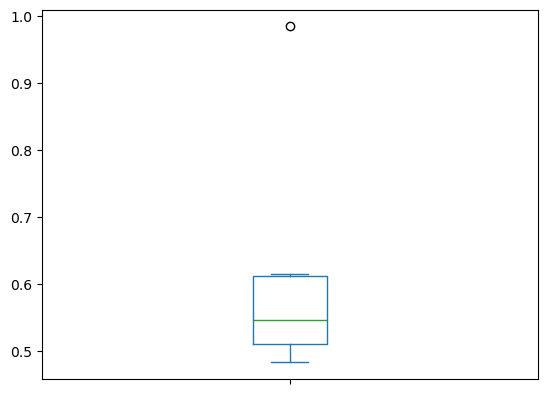

In [194]:
pd.Series(ridge_regressor_alpha_p1_rmses).plot.box()

In [195]:

ridge_regressor_alpha_10_rmses = -cross_val_score(ridge_regressor_alpha_10, 
                                imputed_scaled_possum_train_dataset[possum_select_features],
                                imputed_scaled_possum_train_dataset["hdlngth"],
                                scoring="neg_root_mean_squared_error", cv=10)
pd.Series(ridge_regressor_alpha_10_rmses).describe()

count    10.000000
mean      0.583199
std       0.141189
min       0.453765
25%       0.503640
50%       0.550021
75%       0.600421
max       0.952197
dtype: float64

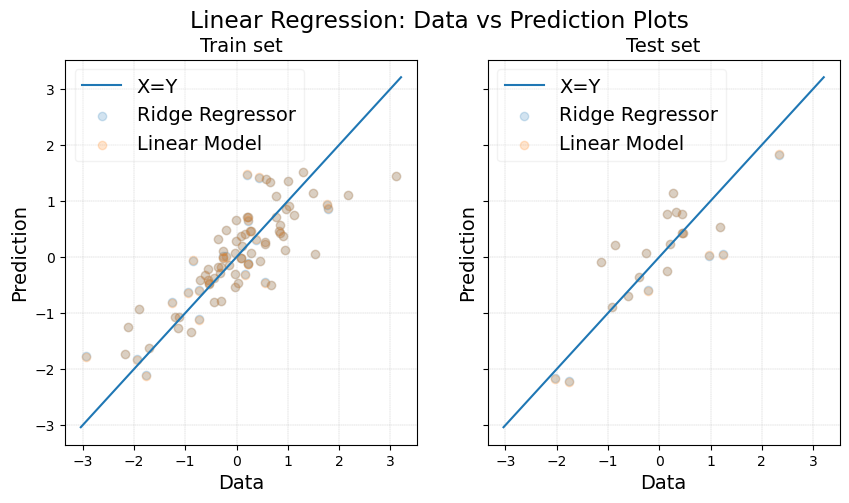

In [196]:
fig, ax = plt.subplots(ncols=2, figsize=(10, 5), sharex=True, sharey=True)
ax[0].grid(linestyle='--', linewidth=0.25)
ax[0].plot(np.linspace(np.min(imputed_scaled_possum_train_dataset['hdlngth'].values)-0.1,
                       np.max(imputed_scaled_possum_train_dataset['hdlngth'].values)+0.1, 
                       num=20),
           np.linspace(np.min(imputed_scaled_possum_train_dataset['hdlngth'].values)-0.1,
                       np.max(imputed_scaled_possum_train_dataset['hdlngth'].values)+0.1, 
                       num=20),
           label="X=Y",
          )
ax[0].scatter(imputed_scaled_possum_train_dataset['hdlngth'].values, 
              ridge_regressor_alpha_1.predict(imputed_scaled_possum_train_dataset[possum_select_features]),  
              alpha=0.2,
              label="Ridge Regressor",
             )
ax[0].scatter(imputed_scaled_possum_train_dataset['hdlngth'].values, 
              possum_data_regressor.predict(imputed_scaled_possum_train_dataset[possum_select_features]),  
              alpha=0.2,
              label="Linear Model",
             )
ax[0].set(xlabel="Data", ylabel="Prediction", title="Train set")
ax[0].legend(loc='best', framealpha=0.25)

ax[1].grid(linestyle='--', linewidth=0.25)
ax[1].plot(np.linspace(np.min(imputed_scaled_possum_train_dataset['hdlngth'].values)-0.1,
                       np.max(imputed_scaled_possum_train_dataset['hdlngth'].values)+0.1, 
                       num=20),
           np.linspace(np.min(imputed_scaled_possum_train_dataset['hdlngth'].values)-0.1,
                       np.max(imputed_scaled_possum_train_dataset['hdlngth'].values)+0.1, 
                       num=20),
           label="X=Y",
          )
ax[1].scatter(imputed_scaled_possum_test_dataset['hdlngth'].values, 
              ridge_regressor_alpha_1.predict(imputed_scaled_possum_test_dataset[possum_select_features]),  
              alpha=0.2,
              label="Ridge Regressor",
             )
ax[1].scatter(imputed_scaled_possum_test_dataset['hdlngth'].values, 
              possum_data_regressor.predict(imputed_scaled_possum_test_dataset[possum_select_features]), 
              alpha=0.2,
              label="Linear Model",
             )
ax[1].set(xlabel="Data", ylabel="Prediction", title="Test set")
ax[1].legend(loc='best', framealpha=0.25)

fig.suptitle("Linear Regression: Data vs Prediction Plots")

plt.show()

In [197]:
imputed_scaled_possum_train_dataset.columns.values

array(['case', 'site', 'age', 'hdlngth', 'skullw', 'totlngth', 'taill',
       'footlgth', 'earconch', 'eye', 'chest', 'belly', 'log_age',
       'exp_dec_age', 'tanh_age'], dtype=object)

In [198]:
possum_select_features_lasso = ['skullw', 'totlngth', 'taill', 'footlgth', 'earconch', 'eye', 'chest', 'belly', 'exp_dec_age']

In [199]:
from sklearn import linear_model
lasso_model = linear_model.Lasso(alpha=0.01)
lasso_model.fit(imputed_scaled_possum_train_dataset[possum_select_features_lasso],
                                imputed_scaled_possum_train_dataset["hdlngth"])

Lasso(alpha=0.01)

In [200]:
lasso_regressor_rmses = -cross_val_score(lasso_model, 
                                imputed_scaled_possum_train_dataset[possum_select_features_lasso],
                                imputed_scaled_possum_train_dataset["hdlngth"],
                                scoring="neg_root_mean_squared_error", cv=10)
pd.Series(lasso_regressor_rmses).describe()

count    10.000000
mean      0.598425
std       0.150945
min       0.473809
25%       0.499637
50%       0.541206
75%       0.650704
max       0.967266
dtype: float64

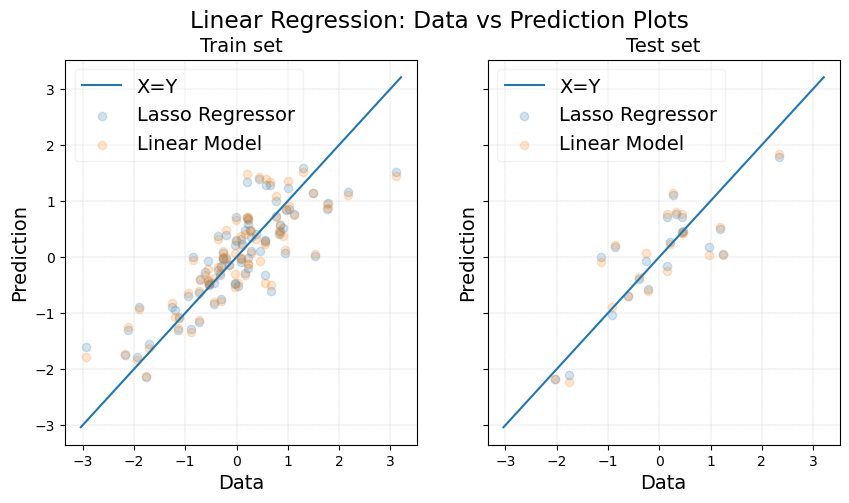

In [201]:
fig, ax = plt.subplots(ncols=2, figsize=(10, 5), sharex=True, sharey=True)
ax[0].grid(linestyle='--', linewidth=0.25)
ax[0].plot(np.linspace(np.min(imputed_scaled_possum_train_dataset['hdlngth'].values)-0.1,
                       np.max(imputed_scaled_possum_train_dataset['hdlngth'].values)+0.1, 
                       num=20),
           np.linspace(np.min(imputed_scaled_possum_train_dataset['hdlngth'].values)-0.1,
                       np.max(imputed_scaled_possum_train_dataset['hdlngth'].values)+0.1, 
                       num=20),
           label="X=Y",
          )
ax[0].scatter(imputed_scaled_possum_train_dataset['hdlngth'].values, 
              lasso_model.predict(imputed_scaled_possum_train_dataset[possum_select_features_lasso]),  
              alpha=0.2,
              label="Lasso Regressor",
             )
ax[0].scatter(imputed_scaled_possum_train_dataset['hdlngth'].values, 
              possum_data_regressor.predict(imputed_scaled_possum_train_dataset[possum_select_features]),  
              alpha=0.2,
              label="Linear Model",
             )
ax[0].set(xlabel="Data", ylabel="Prediction", title="Train set")
ax[0].legend(loc='best', framealpha=0.25)

ax[1].grid(linestyle='--', linewidth=0.25)
ax[1].plot(np.linspace(np.min(imputed_scaled_possum_train_dataset['hdlngth'].values)-0.1,
                       np.max(imputed_scaled_possum_train_dataset['hdlngth'].values)+0.1, 
                       num=20),
           np.linspace(np.min(imputed_scaled_possum_train_dataset['hdlngth'].values)-0.1,
                       np.max(imputed_scaled_possum_train_dataset['hdlngth'].values)+0.1, 
                       num=20),
           label="X=Y",
          )
ax[1].scatter(imputed_scaled_possum_test_dataset['hdlngth'].values, 
              lasso_model.predict(imputed_scaled_possum_test_dataset[possum_select_features_lasso]),  
              alpha=0.2,
              label="Lasso Regressor",
             )
ax[1].scatter(imputed_scaled_possum_test_dataset['hdlngth'].values, 
              possum_data_regressor.predict(imputed_scaled_possum_test_dataset[possum_select_features]), 
              alpha=0.2,
              label="Linear Model",
             )
ax[1].set(xlabel="Data", ylabel="Prediction", title="Test set")
ax[1].legend(loc='best', framealpha=0.25)

fig.suptitle("Linear Regression: Data vs Prediction Plots")

plt.show()

---

## Looks like Linear, Lasso and GB Regressor worked the best

* Compare these via cross validation

---

In [202]:
cross_val_df = pd.DataFrame({
    "Linear": pd.Series(lin_rmses),
    "Lasso": pd.Series(lasso_regressor_rmses),
    "Gradient Boosted": pd.Series(gb_n16_forest_rmses)
    })

In [203]:
cross_val_df

,Linear,Lasso,Gradient Boosted
0,0.614275,0.691429,0.515310
1,0.602837,0.624359,0.706336
2,0.540509,0.515233,0.579337
3,0.615336,0.659486,0.511420
4,0.499816,0.495687,0.459138
5,0.496197,0.478316,0.521279
6,0.542278,0.511487,0.575681
7,0.482592,0.473809,0.544478
8,0.985811,0.967266,0.882424
9,0.550143,0.567178,0.675201


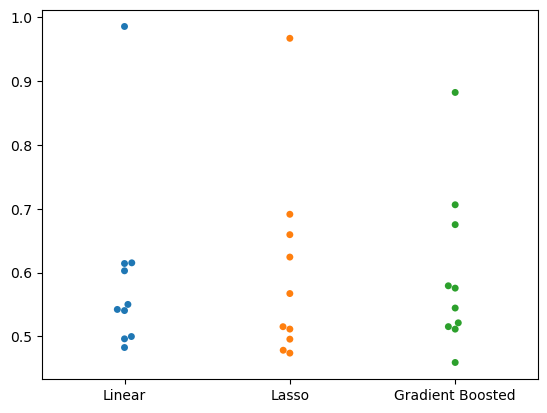

In [204]:
sns.swarmplot(data = cross_val_df)
plt.show()

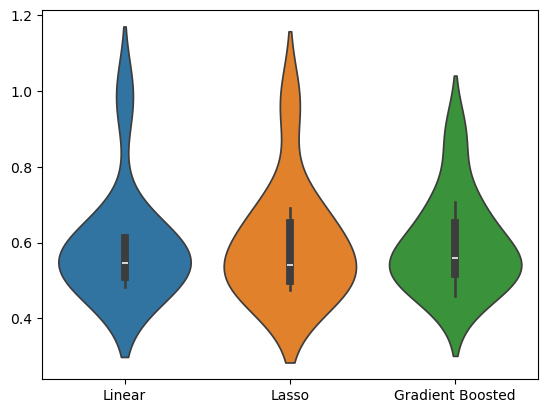

In [205]:
sns.violinplot(data = cross_val_df)
plt.show()

* Try grid search for fine tuning the model
    - Linear
    - Lasso
    - GB Tree models

In [206]:
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV

possum_dataset_gb_pipeline = Pipeline([
    ("impute", SimpleImputer(strategy="median")),
    ("standardize", StandardScaler()),
    ("gb_reg", GradientBoostingRegressor(random_state=42))
])
param_grid_gb = [{'gb_reg__max_depth': [2, 3, 4, 5, 6],
                  'gb_reg__n_estimators': [4, 8, 16]}]
grid_search_gb = GridSearchCV(possum_dataset_gb_pipeline, 
                              param_grid_gb, 
                              cv=10,
                              scoring='neg_root_mean_squared_error')
grid_search_gb.fit(imputed_scaled_possum_train_dataset[possum_select_features],
                   imputed_scaled_possum_train_dataset["hdlngth"])

GridSearchCV(cv=10,
             estimator=Pipeline(steps=[('impute',
                                        SimpleImputer(strategy='median')),
                                       ('standardize', StandardScaler()),
                                       ('gb_reg',
                                        GradientBoostingRegressor(random_state=42))]),
             param_grid=[{'gb_reg__max_depth': [2, 3, 4, 5, 6],
                          'gb_reg__n_estimators': [4, 8, 16]}],
             scoring='neg_root_mean_squared_error')

In [207]:
grid_search_gb.best_params_

{'gb_reg__max_depth': 4, 'gb_reg__n_estimators': 16}

In [214]:
final_model_gb = grid_search_gb.best_estimator_  # includes preprocessing
feature_importances = final_model_gb["gb_reg"].feature_importances_
feature_importances.round(2)

array([0.75, 0.11, 0.08, 0.02, 0.  , 0.03])

In [215]:
imputed_scaled_possum_train_dataset[possum_select_features].columns

Index(['skullw', 'totlngth', 'footlgth', 'chest', 'belly', 'exp_dec_age'], dtype='object')

In [216]:
possum_dataset_dt_pipeline = Pipeline([
    ("impute", SimpleImputer(strategy="median")),
    ("standardize", StandardScaler()),
    ("dt_reg", DecisionTreeRegressor(random_state=42))
])
param_grid_dt = [{'dt_reg__max_depth': [2, 3, 4, 5, 6],
                  'dt_reg__min_samples_leaf': [1, 2, 4, 8],}]
                  #'dt_reg__min_weight_fraction_leaf': [0., 0.05, 0.1, 0.2]}]
grid_search_dt = GridSearchCV(possum_dataset_dt_pipeline, 
                              param_grid_dt, 
                              cv=10,
                              scoring='neg_root_mean_squared_error')
grid_search_dt.fit(imputed_scaled_possum_train_dataset[possum_select_features],
                   imputed_scaled_possum_train_dataset["hdlngth"])

GridSearchCV(cv=10,
             estimator=Pipeline(steps=[('impute',
                                        SimpleImputer(strategy='median')),
                                       ('standardize', StandardScaler()),
                                       ('dt_reg',
                                        DecisionTreeRegressor(random_state=42))]),
             param_grid=[{'dt_reg__max_depth': [2, 3, 4, 5, 6],
                          'dt_reg__min_samples_leaf': [1, 2, 4, 8]}],
             scoring='neg_root_mean_squared_error')

In [217]:
grid_search_dt.best_params_

{'dt_reg__max_depth': 5, 'dt_reg__min_samples_leaf': 4}

In [218]:
final_model_dt = grid_search_dt.best_estimator_  # includes preprocessing
feature_importances = final_model_dt["dt_reg"].feature_importances_
feature_importances.round(2)

array([0.8 , 0.14, 0.02, 0.01, 0.  , 0.03])

In [219]:
imputed_scaled_possum_train_dataset[possum_select_features].columns

Index(['skullw', 'totlngth', 'footlgth', 'chest', 'belly', 'exp_dec_age'], dtype='object')

In [220]:
possum_dataset_lasso_pipeline = Pipeline([
    ("impute", SimpleImputer(strategy="median")),
    ("standardize", StandardScaler()),
    ("lasso_reg", linear_model.Lasso())
])
param_grid_lasso = [{'lasso_reg__alpha': [0.01, 0.02, 0.03, 0.04, 0.05, 0.075, 0.1]}]
grid_search_lasso = GridSearchCV(possum_dataset_lasso_pipeline, 
                              param_grid_lasso, 
                              cv=10,
                              scoring='neg_root_mean_squared_error')
grid_search_lasso.fit(imputed_scaled_possum_train_dataset[possum_select_features_lasso],
                   imputed_scaled_possum_train_dataset["hdlngth"])

GridSearchCV(cv=10,
             estimator=Pipeline(steps=[('impute',
                                        SimpleImputer(strategy='median')),
                                       ('standardize', StandardScaler()),
                                       ('lasso_reg', Lasso())]),
             param_grid=[{'lasso_reg__alpha': [0.01, 0.02, 0.03, 0.04, 0.05,
                                               0.075, 0.1]}],
             scoring='neg_root_mean_squared_error')

In [221]:
grid_search_lasso.best_params_

{'lasso_reg__alpha': 0.04}

In [222]:
final_model_gb_train_pred=grid_search_gb.predict(imputed_scaled_possum_train_dataset[possum_select_features])
final_model_gb_test_pred=grid_search_gb.predict(imputed_scaled_possum_test_dataset[possum_select_features])
print(f"Train Set Root Mean squared error: {root_mean_squared_error(imputed_scaled_possum_train_dataset["hdlngth"], 
                                                                   final_model_gb_train_pred):.2f}")
print(f"Test Set Root Mean squared error: {root_mean_squared_error(imputed_scaled_possum_test_dataset["hdlngth"], 
                                                                   final_model_gb_test_pred):.2f}")

Train Set Root Mean squared error: 0.27
Test Set Root Mean squared error: 0.74


In [223]:
final_model_dt_train_pred=grid_search_dt.predict(imputed_scaled_possum_train_dataset[possum_select_features])
final_model_dt_test_pred=grid_search_dt.predict(imputed_scaled_possum_test_dataset[possum_select_features])
print(f"Train Set Root Mean squared error: {root_mean_squared_error(imputed_scaled_possum_train_dataset["hdlngth"], 
                                                                   final_model_dt_train_pred):.2f}")
print(f"Test Set Root Mean squared error: {root_mean_squared_error(imputed_scaled_possum_test_dataset["hdlngth"], 
                                                                   final_model_dt_test_pred):.2f}")

Train Set Root Mean squared error: 0.38
Test Set Root Mean squared error: 0.57


In [224]:
final_model_lasso_train_pred=grid_search_lasso.predict(imputed_scaled_possum_train_dataset[possum_select_features_lasso])
final_model_lasso_test_pred=grid_search_lasso.predict(imputed_scaled_possum_test_dataset[possum_select_features_lasso])
print(f"Train Set Root Mean squared error: {root_mean_squared_error(imputed_scaled_possum_train_dataset["hdlngth"], 
                                                                   final_model_lasso_train_pred):.2f}")
print(f"Test Set Root Mean squared error: {root_mean_squared_error(imputed_scaled_possum_test_dataset["hdlngth"], 
                                                                   final_model_lasso_test_pred):.2f}")

Train Set Root Mean squared error: 0.55
Test Set Root Mean squared error: 0.56


In [225]:
print("Metrics for Linear Regression Model")
print(f"Train Set Root Mean squared error: {root_mean_squared_error(imputed_scaled_possum_train_dataset["hdlngth"], 
                                                                   possum_data_regressor.predict(imputed_scaled_possum_train_dataset[possum_select_features])):.2f}")
print(f"Test Set Root Mean squared error: {root_mean_squared_error(imputed_scaled_possum_test_dataset["hdlngth"], 
                                                                   possum_data_regressor.predict(imputed_scaled_possum_test_dataset[possum_select_features])):.2f}")

Metrics for Linear Regression Model
Train Set Root Mean squared error: 0.55
Test Set Root Mean squared error: 0.59


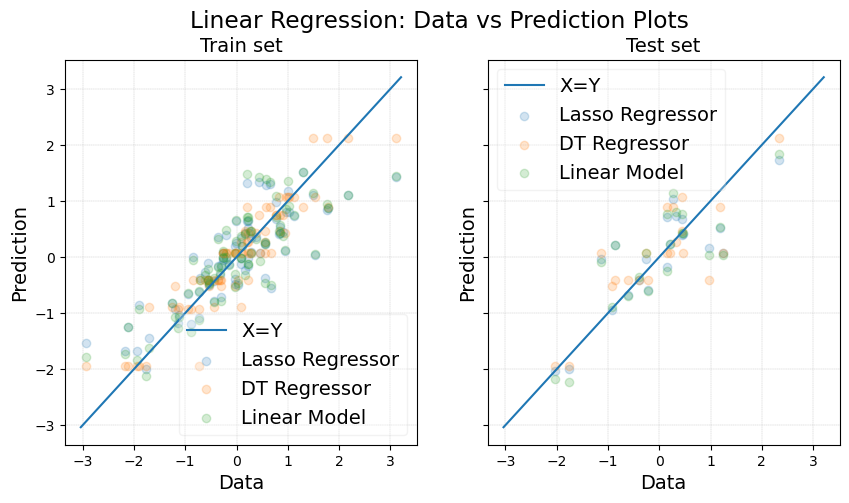

In [226]:
fig, ax = plt.subplots(ncols=2, figsize=(10, 5), sharex=True, sharey=True)
ax[0].grid(linestyle='--', linewidth=0.25)
ax[0].plot(np.linspace(np.min(imputed_scaled_possum_train_dataset['hdlngth'].values)-0.1,
                       np.max(imputed_scaled_possum_train_dataset['hdlngth'].values)+0.1, 
                       num=20),
           np.linspace(np.min(imputed_scaled_possum_train_dataset['hdlngth'].values)-0.1,
                       np.max(imputed_scaled_possum_train_dataset['hdlngth'].values)+0.1, 
                       num=20),
           label="X=Y",
          )
ax[0].scatter(imputed_scaled_possum_train_dataset['hdlngth'].values, 
              grid_search_lasso.predict(imputed_scaled_possum_train_dataset[possum_select_features_lasso]),  
              alpha=0.2,
              label="Lasso Regressor",
             )
ax[0].scatter(imputed_scaled_possum_train_dataset['hdlngth'].values, 
              grid_search_dt.predict(imputed_scaled_possum_train_dataset[possum_select_features]),  
              alpha=0.2,
              label="DT Regressor",
             )
ax[0].scatter(imputed_scaled_possum_train_dataset['hdlngth'].values, 
              possum_data_regressor.predict(imputed_scaled_possum_train_dataset[possum_select_features]),  
              alpha=0.2,
              label="Linear Model",
             )
ax[0].set(xlabel="Data", ylabel="Prediction", title="Train set")
ax[0].legend(loc='best', framealpha=0.25)

ax[1].grid(linestyle='--', linewidth=0.25)
ax[1].plot(np.linspace(np.min(imputed_scaled_possum_train_dataset['hdlngth'].values)-0.1,
                       np.max(imputed_scaled_possum_train_dataset['hdlngth'].values)+0.1, 
                       num=20),
           np.linspace(np.min(imputed_scaled_possum_train_dataset['hdlngth'].values)-0.1,
                       np.max(imputed_scaled_possum_train_dataset['hdlngth'].values)+0.1, 
                       num=20),
           label="X=Y",
          )
ax[1].scatter(imputed_scaled_possum_test_dataset['hdlngth'].values, 
              grid_search_lasso.predict(imputed_scaled_possum_test_dataset[possum_select_features_lasso]),  
              alpha=0.2,
              label="Lasso Regressor",
             )
ax[1].scatter(imputed_scaled_possum_test_dataset['hdlngth'].values, 
              grid_search_dt.predict(imputed_scaled_possum_test_dataset[possum_select_features]),  
              alpha=0.2,
              label="DT Regressor",
             )
ax[1].scatter(imputed_scaled_possum_test_dataset['hdlngth'].values, 
              possum_data_regressor.predict(imputed_scaled_possum_test_dataset[possum_select_features]), 
              alpha=0.2,
              label="Linear Model",
             )
ax[1].set(xlabel="Data", ylabel="Prediction", title="Test set")
ax[1].legend(loc='best', framealpha=0.25)

fig.suptitle("Linear Regression: Data vs Prediction Plots")

plt.show()

In [227]:
from sklearn import tree

In [228]:
dt_best_model = DecisionTreeRegressor(max_depth=5, min_samples_leaf=4, random_state=42)

In [229]:
IMAGES_PATH = Path() / "images" / "end_to_end_project"
IMAGES_PATH.mkdir(parents=True, exist_ok=True)

def save_fig(fig_id, tight_layout=True, fig_extension="png", resolution=300):
    path = IMAGES_PATH / f"{fig_id}.{fig_extension}"
    if tight_layout:
        plt.tight_layout()
    plt.savefig(path, format=fig_extension, dpi=resolution)

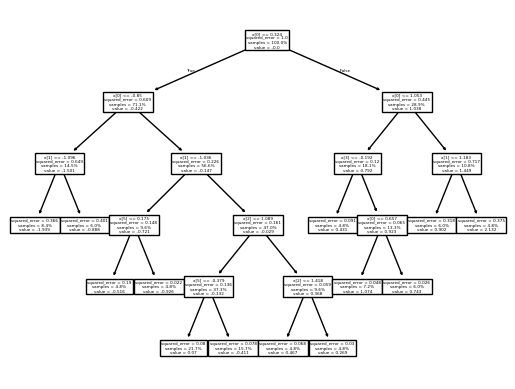

<Figure size 2400x1600 with 0 Axes>

In [230]:
tree.plot_tree(dt_best_model.fit(imputed_scaled_possum_train_dataset[possum_select_features],
                   imputed_scaled_possum_train_dataset["hdlngth"]), proportion=True)
plt.figure(figsize=(24, 16))
plt.show()

---

* PCA
---

In [231]:
from sklearn.decomposition import PCA

In [232]:
pca_possum_dataset = PCA(svd_solver='full')
pca_possum_dataset.fit(imputed_scaled_possum_train_dataset)

PCA(svd_solver='full')

In [233]:
print(pca_possum_dataset.explained_variance_ratio_)

[3.70280623e-01 2.22719781e-01 1.37559318e-01 6.00095745e-02
 5.85762800e-02 4.12334071e-02 3.56800728e-02 2.34557144e-02
 1.60368295e-02 1.45679520e-02 9.69831291e-03 8.03571757e-03
 1.33683480e-03 7.82330208e-04 2.72518988e-05]


In [234]:
pca_possum_dataset.explained_variance_ratio_[:4]

array([0.37028062, 0.22271978, 0.13755932, 0.06000957])

In [235]:
np.around(np.sum(pca_possum_dataset.explained_variance_ratio_[:4]),3)

np.float64(0.791)

In [236]:
np.around(np.sum(pca_possum_dataset.explained_variance_ratio_[:7]),3)

np.float64(0.926)

In [237]:
print(abs(pca_possum_dataset.components_))

[[2.59425074e-01 2.42016924e-01 2.72392828e-01 3.22034889e-01
  2.51008149e-01 2.92024459e-01 6.86801026e-02 2.64864669e-01
  1.72209919e-01 1.43852528e-01 3.18829961e-01 2.73276958e-01
  2.96279813e-01 2.88540560e-01 2.74496745e-01]
 [3.89301697e-01 4.05421278e-01 2.35461239e-01 6.57967311e-02
  7.84929129e-02 3.38262496e-03 2.65811245e-01 3.55827541e-01
  4.29841644e-01 1.66015892e-01 5.74559218e-02 6.21939574e-02
  2.73595403e-01 2.70032716e-01 2.31513792e-01]
 [9.20435248e-02 1.32238955e-01 2.77125129e-01 2.74202907e-01
  3.30023309e-01 3.42186603e-01 3.88224620e-01 3.88760585e-02
  1.72724140e-01 1.26864404e-01 1.87268826e-01 2.05188948e-01
  3.22629767e-01 3.39242650e-01 3.18657577e-01]
 [2.30049550e-02 6.43774095e-03 5.79204396e-02 1.82540012e-01
  4.41511452e-01 3.92497365e-01 5.79936968e-01 1.10773565e-01
  1.19287860e-01 4.63295026e-01 1.55963292e-01 5.44537493e-02
  4.82007037e-02 5.16250730e-02 6.33986690e-02]
 [1.87326722e-01 1.54277378e-01 5.88599381e-02 9.10745472e-02
  

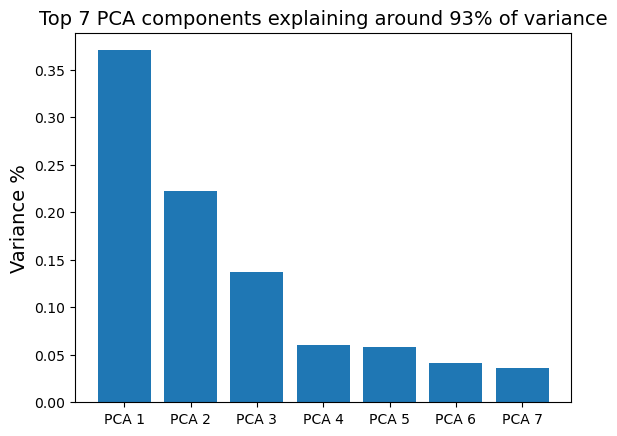

In [238]:
fig, ax = plt.subplots()

ax.bar(['PCA 1', 'PCA 2', 'PCA 3', 'PCA 4', 'PCA 5', 'PCA 6', 'PCA 7'],
pca_possum_dataset.explained_variance_ratio_[:7])

ax.set_ylabel('Variance %')
ax.set_title('Top 7 PCA components explaining around 93% of variance')

plt.show()

In [239]:
pca_possum_dataset_5_components = PCA(n_components=5, svd_solver='full')
pca_possum_dataset_5_components.fit(imputed_scaled_possum_train_dataset)

PCA(n_components=5, svd_solver='full')

In [241]:
print(pca_possum_dataset_5_components.explained_variance_ratio_)

[0.37028062 0.22271978 0.13755932 0.06000957 0.05857628]


In [242]:
np.around(np.sum(pca_possum_dataset_5_components.explained_variance_ratio_),3)

np.float64(0.849)

In [243]:
print(abs(pca_possum_dataset_5_components.components_))

[[0.25942507 0.24201692 0.27239283 0.32203489 0.25100815 0.29202446
  0.0686801  0.26486467 0.17220992 0.14385253 0.31882996 0.27327696
  0.29627981 0.28854056 0.27449675]
 [0.3893017  0.40542128 0.23546124 0.06579673 0.07849291 0.00338262
  0.26581124 0.35582754 0.42984164 0.16601589 0.05745592 0.06219396
  0.2735954  0.27003272 0.23151379]
 [0.09204352 0.13223896 0.27712513 0.27420291 0.33002331 0.3421866
  0.38822462 0.03887606 0.17272414 0.1268644  0.18726883 0.20518895
  0.32262977 0.33924265 0.31865758]
 [0.02300495 0.00643774 0.05792044 0.18254001 0.44151145 0.39249737
  0.57993697 0.11077357 0.11928786 0.46329503 0.15596329 0.05445375
  0.0482007  0.05162507 0.06339867]
 [0.18732672 0.15427738 0.05885994 0.09107455 0.17239335 0.1465618
  0.25189078 0.06098383 0.03475383 0.75988748 0.37673098 0.29088253
  0.0214735  0.03469944 0.0643385 ]]


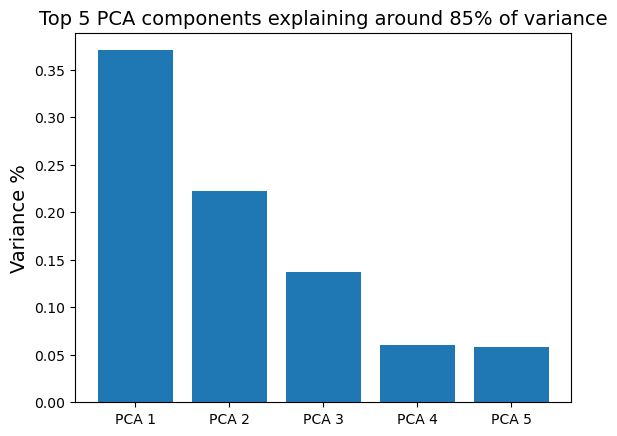

In [245]:
fig, ax = plt.subplots()

ax.bar(['PCA 1', 'PCA 2', 'PCA 3', 'PCA 4', 'PCA 5'],
pca_possum_dataset_5_components.explained_variance_ratio_)

ax.set_ylabel('Variance %')
ax.set_title('Top 5 PCA components explaining around 85% of variance')

plt.show()

---

* Work with more complex data of snow depth at Ski resort
  
* Generate a regression or model predicting numerical values

* Generate a classification model to predict good or bad ski week

---